In [1]:
import requests
import pandas as pd
import numpy as np


# Market 1 - Kalshi - Will S&P500 finish positive this year
https://kalshi.com/markets/kxinxpos/sp500-positive-this-year/kxinxpos-25dec31h1600

In [167]:
markets_url = f"https://api.elections.kalshi.com/trade-api/v2/markets?series_ticker=KXINXPOS&status=open"
markets_response = requests.get(markets_url)
markets_data = markets_response.json()

event_tickers = []
print(f"\nActive markets in KXINXY series:")
for market in markets_data['markets']:
    print(f"- {market['ticker']}: {market['title']}")
    print(f"  Event: {market['event_ticker']}")
    event_tickers.append(market['event_ticker'])



Active markets in KXINXY series:
- KXINXPOS-25DEC31H1600-T5881.63: Will the S&P 500 be above 5881.63 on Dec 31, 2025 at 4pm EST?
  Event: KXINXPOS-25DEC31H1600


In [168]:
from pprint import pprint

def print_market_info(ticker):
    url = f"https://api.elections.kalshi.com/trade-api/v2/markets/{ticker}"
    response = requests.get(url)
    pprint(response.json())

print_market_info('KXINXPOS-25DEC31H1600-T5881.63')

{'market': {'can_close_early': True,
            'category': '',
            'close_time': '2025-12-31T21:00:00Z',
            'created_time': '2025-05-07T16:31:42.897512Z',
            'event_ticker': 'KXINXPOS-25DEC31H1600',
            'expected_expiration_time': '2025-12-31T21:00:00Z',
            'expiration_time': '2026-01-08T00:00:00Z',
            'expiration_value': '',
            'floor_strike': 5881.63,
            'last_price': 97,
            'last_price_dollars': '0.9700',
            'latest_expiration_time': '2026-01-08T00:00:00Z',
            'liquidity': 5810188,
            'liquidity_dollars': '58101.8800',
            'market_type': 'binary',
            'no_ask': 4,
            'no_ask_dollars': '0.0400',
            'no_bid': 1,
            'no_bid_dollars': '0.0100',
            'no_sub_title': 'Positive Growth',
            'notional_value': 100,
            'notional_value_dollars': '1.0000',
            'open_interest': 140892,
            'open_time': '2025

In [169]:
import requests
import time
from datetime import datetime, timezone

def get_candlestick_data(event_ticker, start_ts_str):
    """
    event_ticker: str
    start_ts_str: str, in 'mm/dd/yyyy' format (e.g. '05/01/2024')
    Sets the start and end time exactly at 00:00:00 UTC (2025-11-13T00:00:00Z, etc).
    """
    url = f"https://api.elections.kalshi.com/trade-api/v2/series/KXINXY/markets/{event_ticker}/candlesticks"

    # Parse user input start date in mm/dd/yyyy format and set time to exactly 00:00:00 UTC
    try:
        start_dt = datetime.strptime(start_ts_str, "%m/%d/%Y").replace(hour=0, minute=0, second=0, microsecond=0, tzinfo=timezone.utc)
        start_ts = int(start_dt.timestamp())
    except ValueError:
        print("start_ts must be in 'mm/dd/yyyy' format.")
        return None

    # Set end time at exactly 00:00:00 UTC of the next day (exclusive upper bound)
    now_utc = datetime.now(timezone.utc)
    end_midnight_utc = datetime(year=now_utc.year, month=now_utc.month, day=now_utc.day, hour=0, minute=0, second=0, microsecond=0, tzinfo=timezone.utc)
    # Next day's 00:00:00 UTC
    end_midnight_utc_next = end_midnight_utc + pd.Timedelta(days=1)
    end_ts = int(end_midnight_utc_next.timestamp())

    period_interval = 1440  # 1 day

    params = {
        "start_ts": start_ts,
        "end_ts": end_ts,
        "period_interval": period_interval
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        candlestick_data = response.json()
        print(candlestick_data)
        
        if "candlesticks" in candlestick_data and isinstance(candlestick_data["candlesticks"], list):
            df = pd.DataFrame(candlestick_data["candlesticks"])
            return df
        else:
            print("No candlestick data found.")
            return None
    else:
        print(f"Failed to fetch candlestick data: {response.status_code}")
        return None

In [170]:
df = get_candlestick_data('KXINXPOS-25DEC31H1600-T5881.63','05/08/2025')

{'candlesticks': [{'end_period_ts': 1746763200, 'open_interest': 0, 'price': {'close': None, 'high': None, 'low': None, 'max': None, 'mean': None, 'min': None, 'open': None, 'previous': None}, 'volume': 0, 'yes_ask': {'close': 100, 'close_dollars': '1.0000', 'high': 100, 'high_dollars': '1.0000', 'low': 99, 'low_dollars': '0.9900', 'open': 100, 'open_dollars': '1.0000'}, 'yes_bid': {'close': 0, 'close_dollars': '0.0000', 'high': 50, 'high_dollars': '0.5000', 'low': 0, 'low_dollars': '0.0000', 'open': 1, 'open_dollars': '0.0100'}}, {'end_period_ts': 1746849600, 'open_interest': 117, 'price': {'close': 40, 'close_dollars': '0.4000', 'high': 40, 'high_dollars': '0.4000', 'low': 39, 'low_dollars': '0.3900', 'max': None, 'mean': 39, 'mean_dollars': '0.3987', 'min': None, 'open': 40, 'open_dollars': '0.4000', 'previous': None}, 'volume': 117, 'yes_ask': {'close': 39, 'close_dollars': '0.3900', 'high': 100, 'high_dollars': '1.0000', 'low': 39, 'low_dollars': '0.3900', 'open': 100, 'open_dolla

In [171]:
df.iloc[100]['price']

{'close': 82,
 'close_dollars': '0.8200',
 'high': 82,
 'high_dollars': '0.8200',
 'low': 81,
 'low_dollars': '0.8100',
 'max': None,
 'mean': 81,
 'mean_dollars': '0.8160',
 'min': None,
 'open': 81,
 'open_dollars': '0.8100',
 'previous': 81,
 'previous_dollars': '0.8100'}

In [172]:
df.head(1)

,end_period_ts,open_interest,price,volume,yes_ask,yes_bid
0,1746763200,0,"{'close': None, 'high': None, 'low': None, 'ma...",0,"{'close': 100, 'close_dollars': '1.0000', 'hig...","{'close': 0, 'close_dollars': '0.0000', 'high'..."


In [173]:
df['volume'].describe()


count      205.000000
mean      1321.463415
std       4333.064951
min          0.000000
25%          6.000000
50%        100.000000
75%        537.000000
max      42618.000000
Name: volume, dtype: float64

In [174]:
# Improved extraction of columns and handle missing/None values appropriately
def safe_float(val):
    try:
        if val is None:
            return None
        return float(val)
    except (TypeError, ValueError):
        return None

df_new = pd.DataFrame({
    'end_period': pd.to_datetime(df['end_period_ts'], unit='s').dt.strftime('%m/%d/%Y'),
    'open_interest': df['open_interest'],
    # Convert close values to float, or None if missing
    'close': df['price'].apply(lambda x: safe_float(x.get('close_dollars')) if isinstance(x, dict) else None),
    # Use raw 'volume' column if present, else try extracting from price, and cast to float or int
    'volume': (
        df['volume']
            if 'volume' in df.columns
            else df['price'].apply(lambda x: safe_float(x.get('volume')) if isinstance(x, dict) else None)
    )
})
df_new

,end_period,open_interest,close,volume
0,05/09/2025,0,NaN,0
1,05/10/2025,117,0.40,117
2,05/11/2025,138,0.37,21
3,05/12/2025,354,0.39,245
4,05/13/2025,428,0.54,74
...,...,...,...,...
200,11/25/2025,129766,0.93,7572
201,11/26/2025,145242,0.96,17458
202,11/27/2025,139468,0.96,42618
203,11/28/2025,139664,0.98,1248


In [175]:
df_new = df_new.dropna()


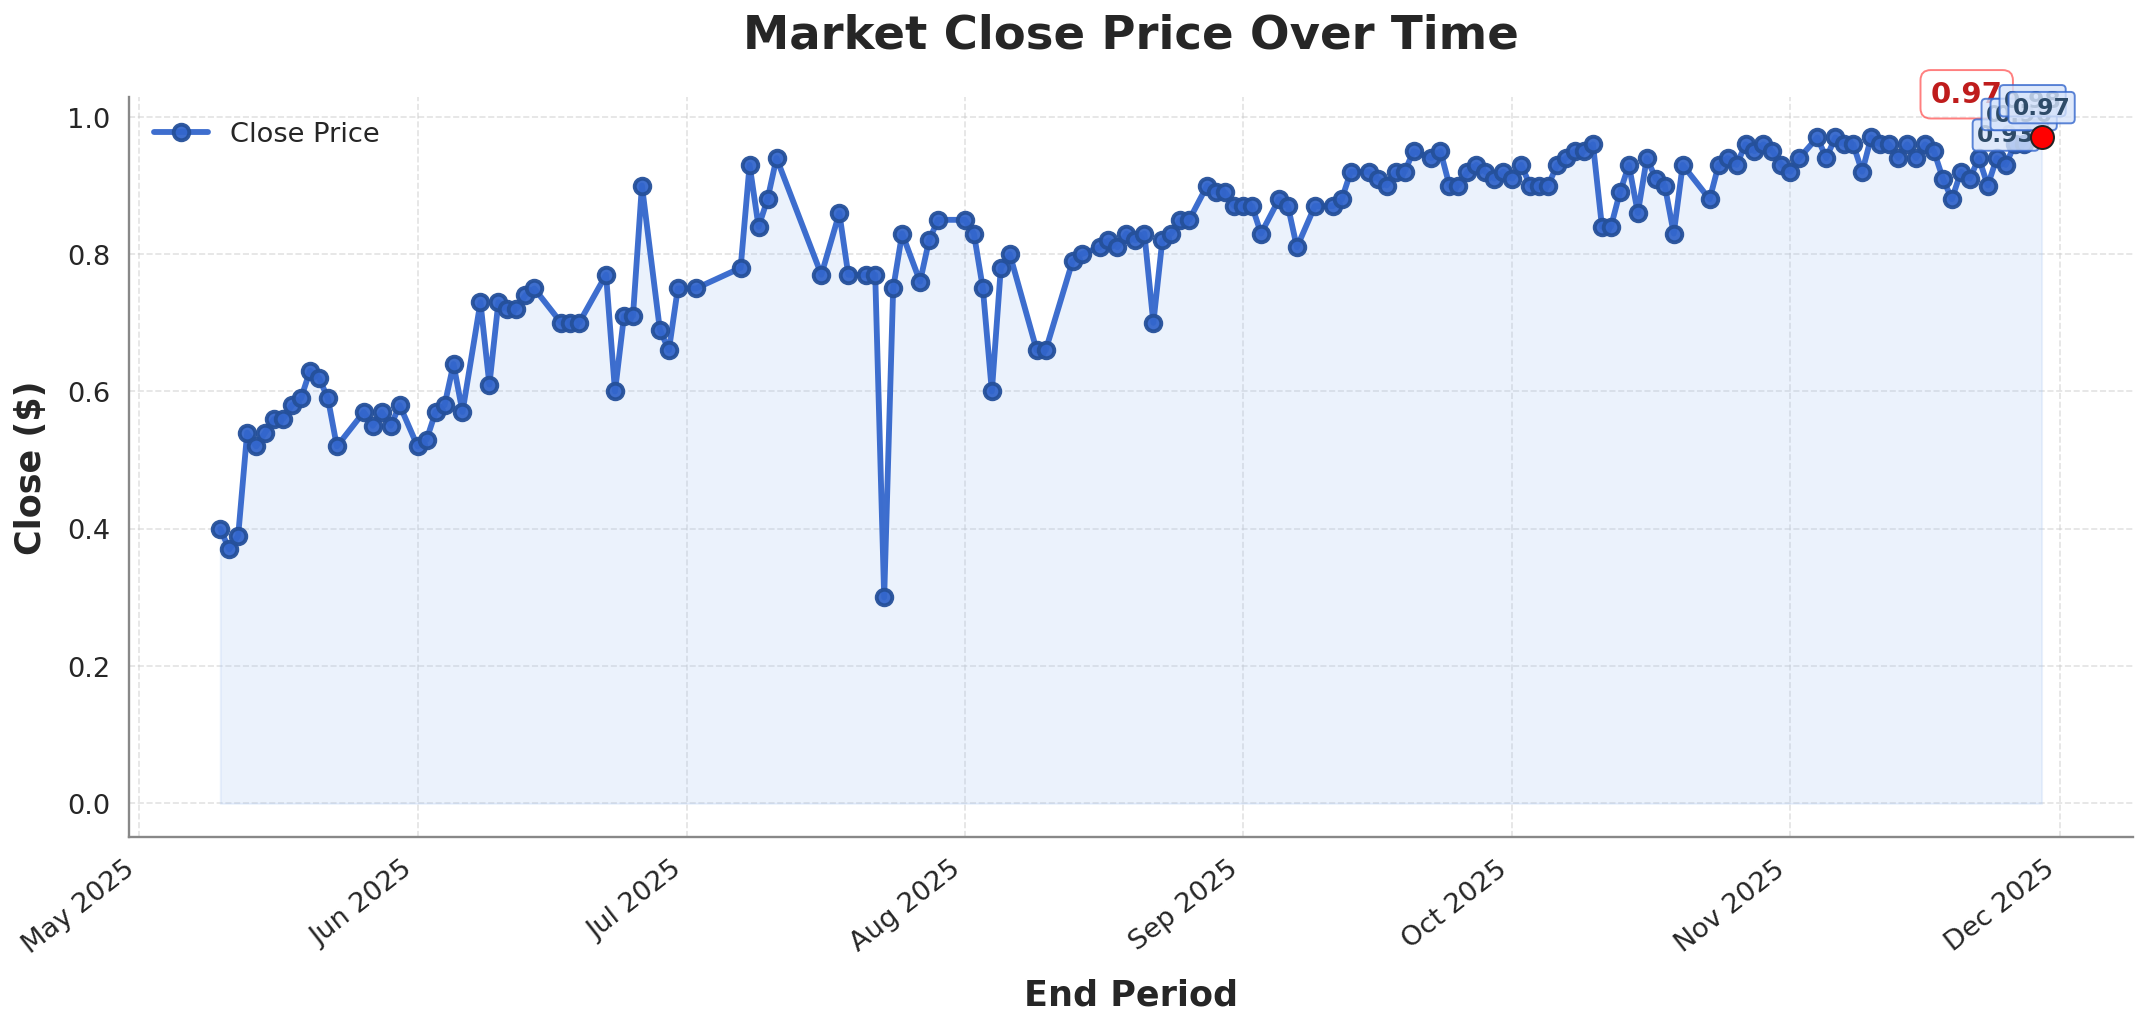

In [176]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(16, 8), dpi=140)

# Convert end_period to datetime if not already
if not hasattr(df_new['end_period'].iloc[0], 'year'):
    dates = pd.to_datetime(df_new['end_period'])
else:
    dates = df_new['end_period']

# Plot with a bold line and gradient fill
ax.plot(dates, df_new['close'], color='#3366cc', linewidth=3, marker='o', markersize=8,
        markeredgewidth=2, markeredgecolor='#25509A', label='Close Price', alpha=0.95)
ax.fill_between(dates, df_new['close'], color='#a7c5f3', alpha=0.22)

# Highlight the latest point
ax.scatter(dates.iloc[-1], df_new['close'].iloc[-1], color='#F00', edgecolor='#222', s=140, zorder=5)
ax.annotate(
    f"{df_new['close'].iloc[-1]:.2f}",
    (dates.iloc[-1], df_new['close'].iloc[-1]),
    textcoords="offset points", xytext=(-20,15),
    ha='right', va='bottom', fontsize=15, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#FF0000', alpha=0.5),
    color='#BF1C1C'
)

# Axis styling
ax.set_xlabel('End Period', fontsize=18, labelpad=10, fontweight='bold')
ax.set_ylabel('Close ($)', fontsize=18, labelpad=10, fontweight='bold')
ax.set_title('Market Close Price Over Time', fontsize=24, fontweight='bold', pad=25)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=38, ha='right', fontsize=14)
plt.setp(ax.get_yticklabels(), fontsize=14)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.85, alpha=0.55, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Add value labels for the most recent five points
for x, y in zip(dates.iloc[-5:], df_new['close'].iloc[-5:]):
    ax.annotate(f"{y:.2f}", (x, y),
                textcoords="offset points", xytext=(0,12), ha='center',
                fontsize=12, color='#2E4B68', weight='bold',
                bbox=dict(boxstyle='round,pad=0.18', fc='#D7E4FB', alpha=0.8, ec='#3366cc'))

ax.legend(fontsize=14, loc="upper left", frameon=False)
plt.tight_layout(pad=2.6)
plt.show()


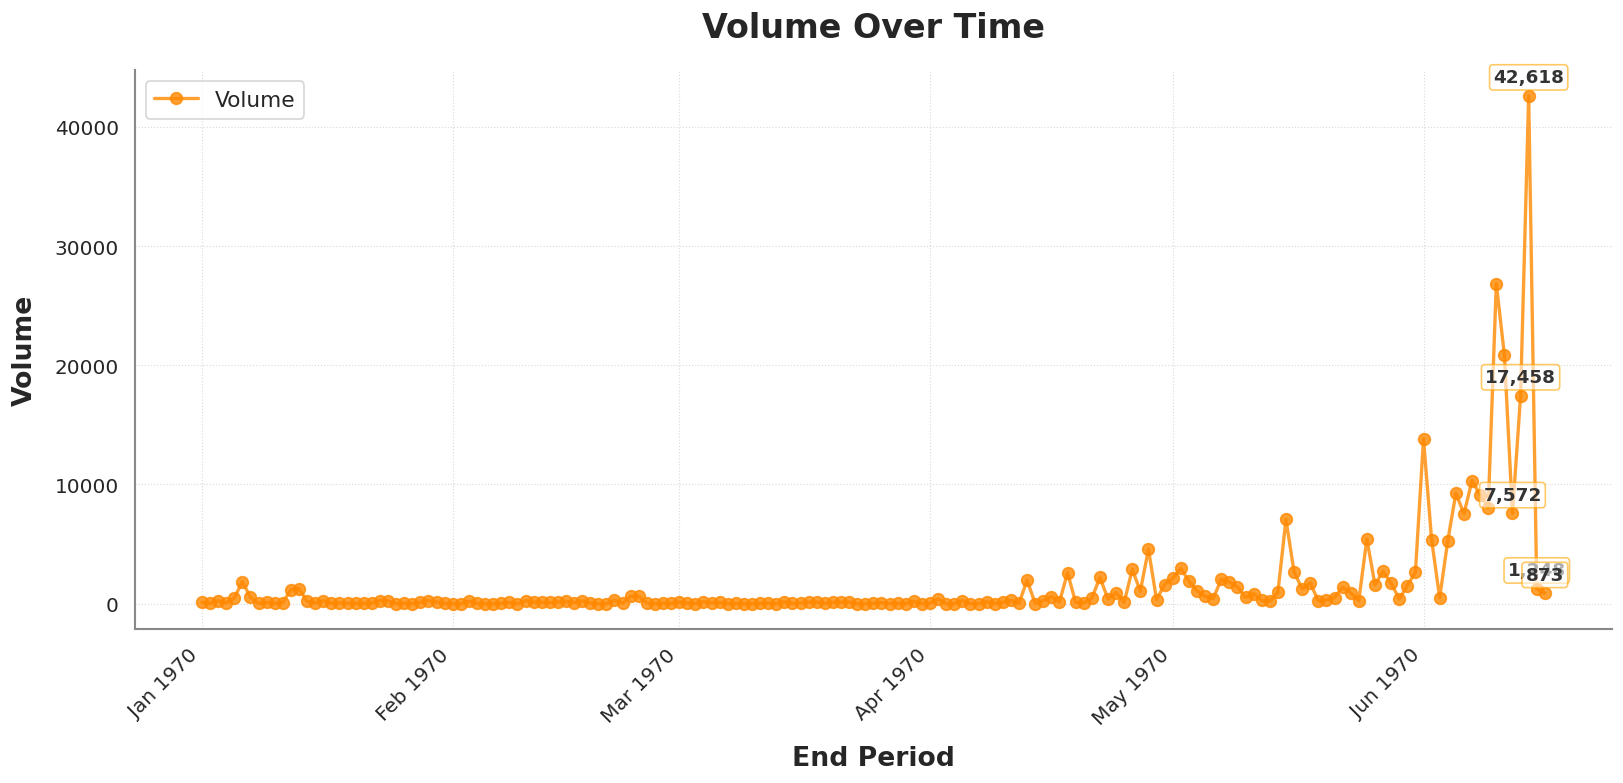

In [177]:
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
ax.plot(
    df_new['end_period'], df_new['volume'],
    marker='o', linestyle='-', color='#FF8800', linewidth=2, markersize=7, alpha=0.8,
    label='Volume'
)
ax.set_xlabel('End Period', fontsize=16, labelpad=10, fontweight='bold')
ax.set_ylabel('Volume', fontsize=16, labelpad=10, fontweight='bold')
ax.set_title('Volume Over Time', fontsize=20, fontweight='bold', pad=20)
ax.grid(visible=True, which='major', linestyle=':', linewidth=0.7, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use a more readable date formatter
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(ax.get_yticklabels(), fontsize=12)

# Add value labels for recent points
for x, y in zip(df_new['end_period'][-5:], df_new['volume'][-5:]):
    ax.annotate(f"{int(y):,}", (x, y),
            textcoords="offset points", xytext=(0,8), ha='center',
            fontsize=11, color='#333333', weight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor='orange'))

ax.legend(fontsize=13)
plt.tight_layout(pad=2)
plt.show()


In [178]:
import yfinance as yf
from datetime import datetime

# Define start and end dates
start_date = "2025-05-10"
end_date = datetime.today().strftime('%Y-%m-%d')  # today's date

# Download S&P 500 index data ('^GSPC') from Yahoo Finance
sp500 = yf.download("^GSPC", start=start_date, end=end_date, auto_adjust=True)

# Reset index so that 'Date' becomes a column, and rename for clarity
sp500 = sp500.reset_index()
sp500 = sp500.rename(columns={'Date': 'date', 'Close': 'sp500_close', 'Volume': 'volume'})

# Select only necessary columns
sp500 = sp500[['date', 'sp500_close', 'volume']]

# Set 'date' as index if needed
sp500 = sp500.set_index('date')
sp500 = sp500.droplevel(1, axis=1)

# Show the head of the dataframe as a check
sp500.head()


[*********************100%***********************]  1 of 1 completed


Price,sp500_close,volume
date,,
2025-05-12,5844.189941,6014580000
2025-05-13,5886.549805,5516290000
2025-05-14,5892.580078,5233450000
2025-05-15,5916.930176,4991290000
2025-05-16,5958.379883,4850850000


In [179]:
# Ensure df_new['end_period'] is datetime
df_new['end_period'] = pd.to_datetime(df_new['end_period'])

# Use the sp500 index (already datetime) for merging
sp500_reset = sp500.reset_index()
sp500_reset['spy_volume'] = sp500_reset['volume']
sp500_reset.drop(columns=['volume'], inplace=True)
sp500_reset['date'] = pd.to_datetime(sp500_reset['date'])

# Use 'left' join to preserve all rows in df_new
merged_df = df_new.merge(sp500_reset, left_on='end_period', right_on='date', how='left')


C:\Users\jmani\AppData\Local\Temp\ipykernel_16396\3094184836.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['end_period'] = pd.to_datetime(df_new['end_period'])


In [180]:
merged_df.drop(columns=['date'], inplace=True)
merged_df.dropna(inplace=True)
merged_df

,end_period,open_interest,close,volume,sp500_close,spy_volume
2,2025-05-12,354,0.39,245,5844.189941,6.014580e+09
3,2025-05-13,428,0.54,74,5886.549805,5.516290e+09
4,2025-05-14,853,0.52,472,5892.580078,5.233450e+09
5,2025-05-15,2410,0.54,1855,5916.930176,4.991290e+09
6,2025-05-16,2847,0.56,537,5958.379883,4.850850e+09
...,...,...,...,...,...,...
158,2025-11-21,100621,0.91,9121,6602.990234,5.929930e+09
161,2025-11-24,127273,0.94,20850,6705.120117,6.039740e+09
162,2025-11-25,129766,0.93,7572,6765.879883,5.003330e+09
163,2025-11-26,145242,0.96,17458,6812.609863,4.485000e+09


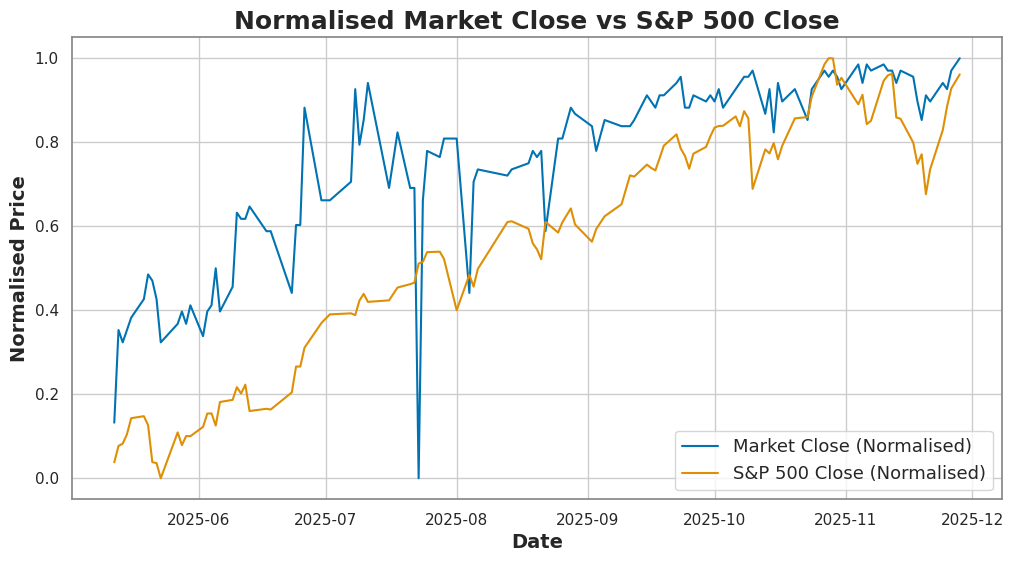

In [181]:
import matplotlib.pyplot as plt

# Set 'end_period' as the index
plot_df = merged_df.set_index('end_period')

# Normalise the columns to [0,1] using min-max normalisation
close_norm = (plot_df['close'] - plot_df['close'].min()) / (plot_df['close'].max() - plot_df['close'].min())
sp500_close_norm = (plot_df['sp500_close'] - plot_df['sp500_close'].min()) / (plot_df['sp500_close'].max() - plot_df['sp500_close'].min())

plt.figure(figsize=(12,6))
plt.plot(plot_df.index, close_norm, label='Market Close (Normalised)')
plt.plot(plot_df.index, sp500_close_norm, label='S&P 500 Close (Normalised)')
plt.xlabel('Date')
plt.ylabel('Normalised Price')
plt.title('Normalised Market Close vs S&P 500 Close')
plt.legend()
plt.show()


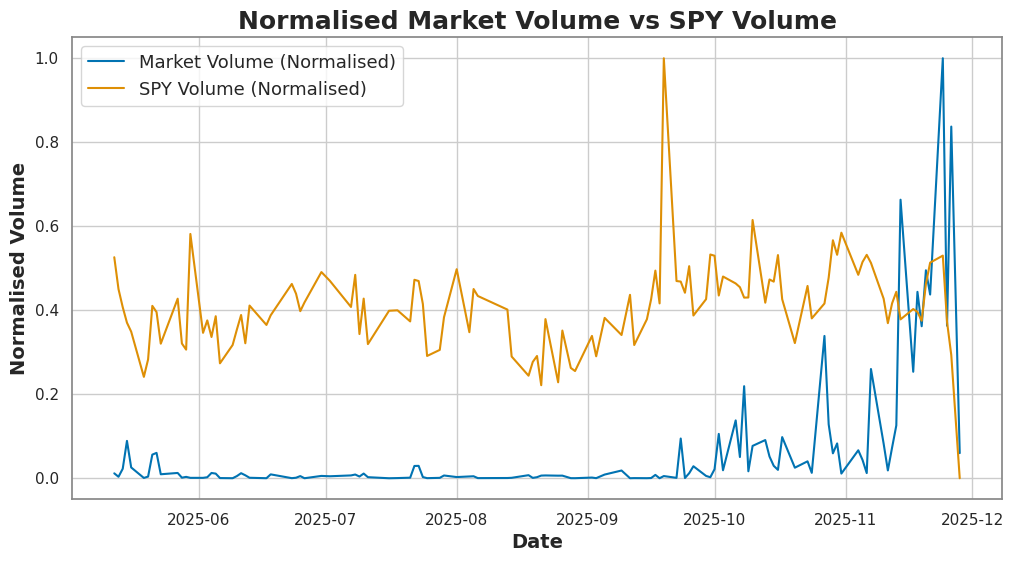

In [182]:
# Plot volume and spy_volume normalised

# Normalise 'volume' and 'spy_volume' columns to [0,1]
volume_norm = (plot_df['volume'] - plot_df['volume'].min()) / (plot_df['volume'].max() - plot_df['volume'].min())
spy_volume_norm = (plot_df['spy_volume'] - plot_df['spy_volume'].min()) / (plot_df['spy_volume'].max() - plot_df['spy_volume'].min())

plt.figure(figsize=(12,6))
plt.plot(plot_df.index, volume_norm, label='Market Volume (Normalised)')
plt.plot(plot_df.index, spy_volume_norm, label='SPY Volume (Normalised)')
plt.xlabel('Date')
plt.ylabel('Normalised Volume')
plt.title('Normalised Market Volume vs SPY Volume')
plt.legend()
plt.show()


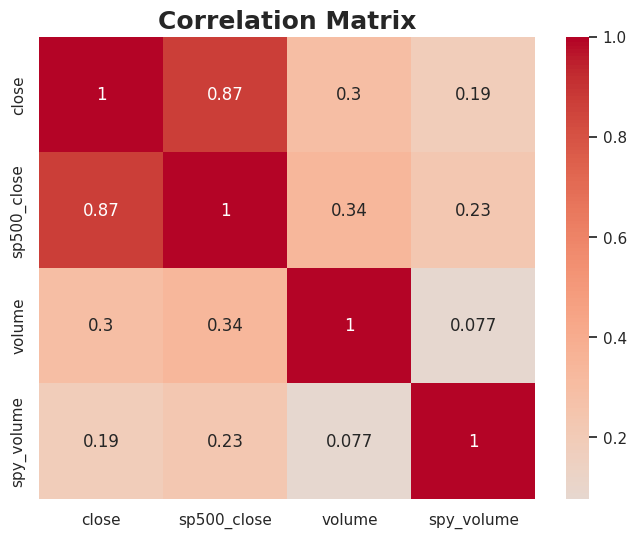

In [183]:
# Plot a correlation matrix for the relevant columns
import seaborn as sns

# Compute correlation matrix for numerical columns
corr = plot_df[['close', 'sp500_close', 'volume', 'spy_volume']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


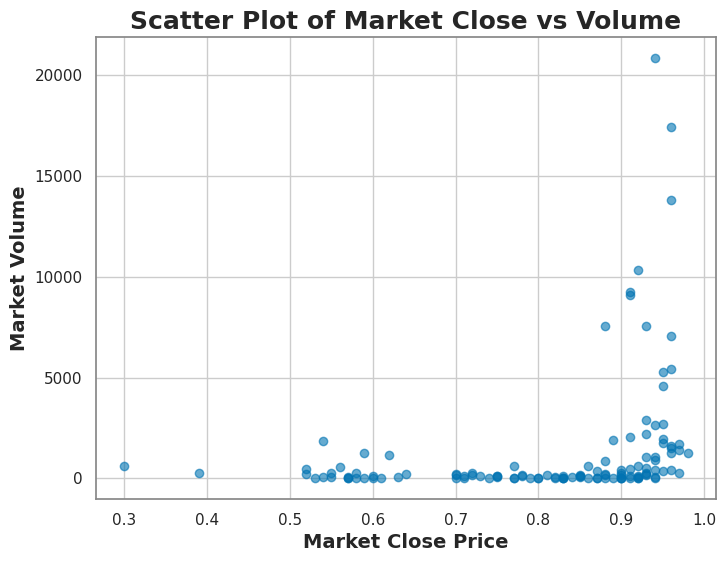

Pearson correlation between close and volume: 0.297


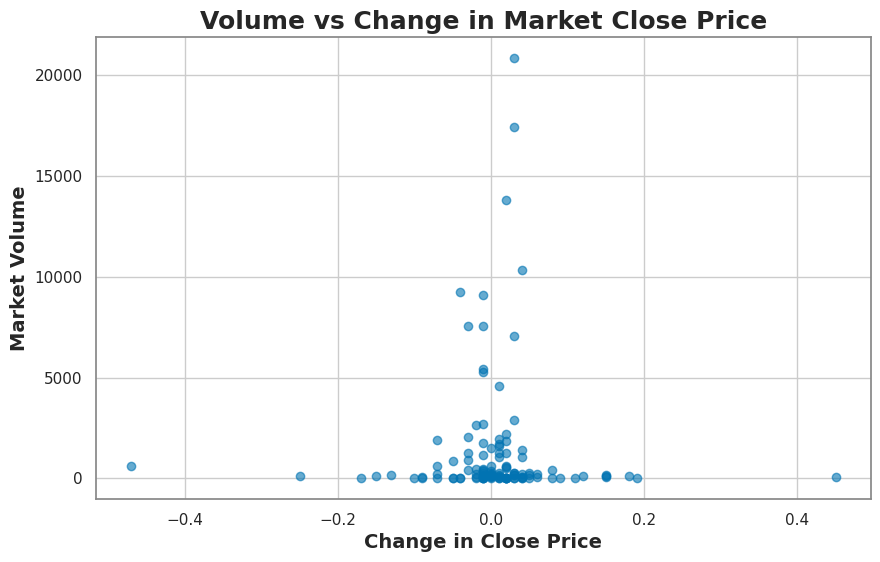

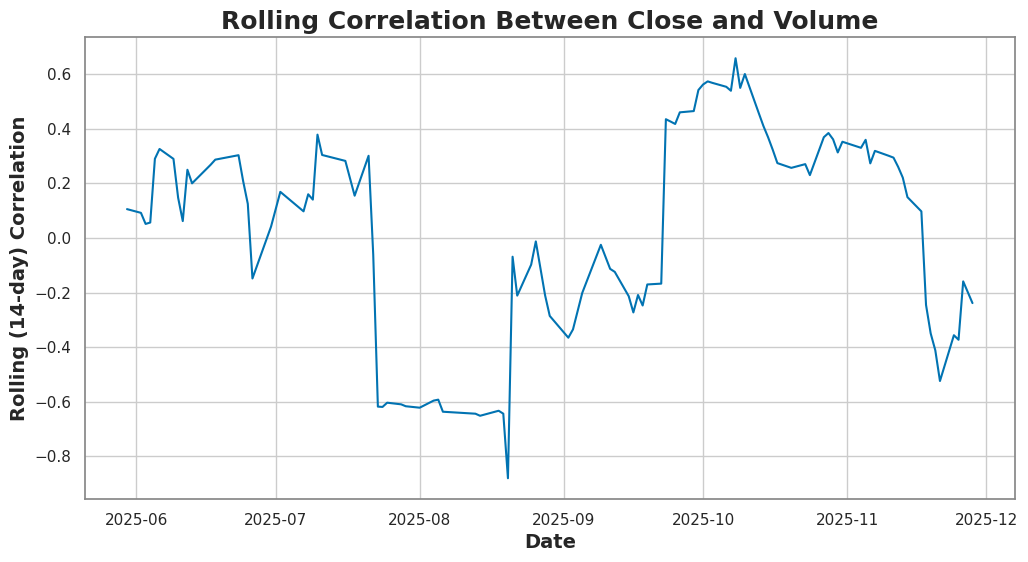

In [184]:
# Analyze the relationship between 'close' and 'volume'

# Scatter plot to visualize relationship
plt.figure(figsize=(8,6))
plt.scatter(plot_df['close'], plot_df['volume'], alpha=0.6)
plt.xlabel('Market Close Price')
plt.ylabel('Market Volume')
plt.title('Scatter Plot of Market Close vs Volume')
plt.show()

# Calculate Pearson correlation coefficient
corr_close_volume = plot_df['close'].corr(plot_df['volume'])
print(f"Pearson correlation between close and volume: {corr_close_volume:.3f}")

# Explore if volume spikes occur at specific price changes
plot_df['price_change'] = plot_df['close'].diff()
plt.figure(figsize=(10,6))
plt.scatter(plot_df['price_change'], plot_df['volume'], alpha=0.6)
plt.xlabel('Change in Close Price')
plt.ylabel('Market Volume')
plt.title('Volume vs Change in Market Close Price')
plt.show()

# Optionally, look at moving correlations (over a window)
window = 14
rolling_corr = plot_df['close'].rolling(window).corr(plot_df['volume'])
plt.figure(figsize=(12,6))
plt.plot(plot_df.index, rolling_corr)
plt.xlabel('Date')
plt.ylabel(f'Rolling ({window}-day) Correlation')
plt.title('Rolling Correlation Between Close and Volume')
plt.show()



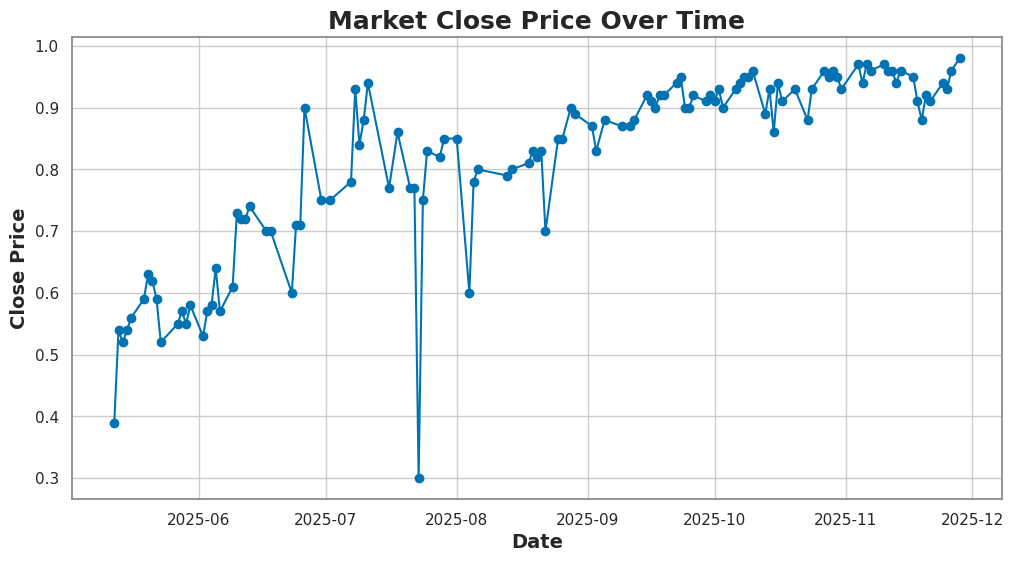

Summary statistics for 'close':
count    118.000000
mean       0.812542
std        0.149324
min        0.300000
25%        0.722500
50%        0.870000
75%        0.930000
max        0.980000
Name: close, dtype: float64


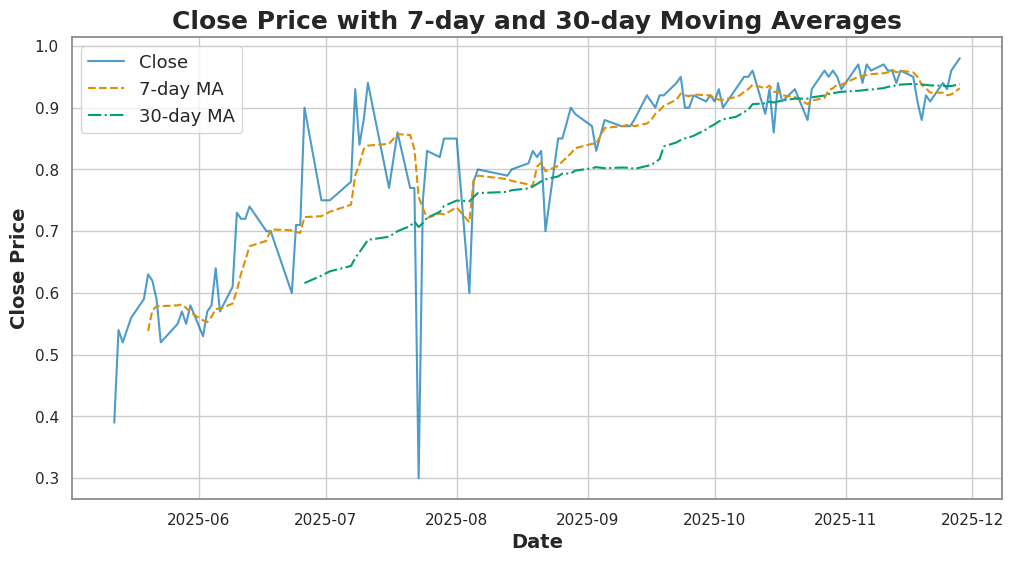

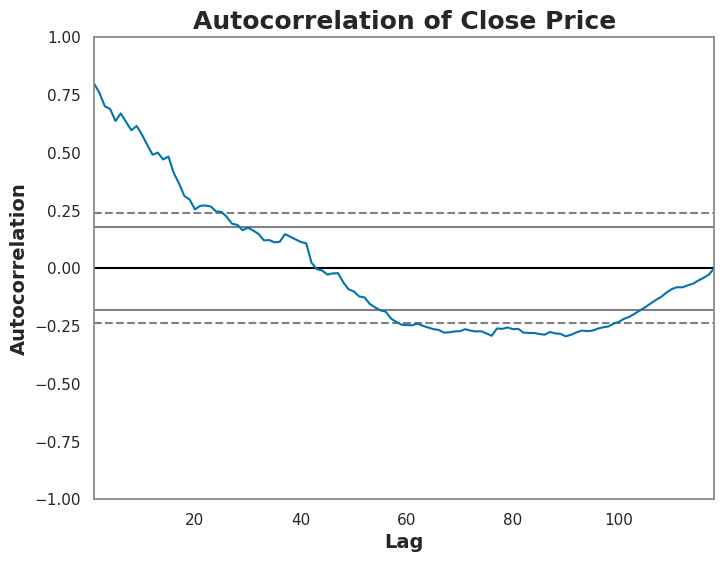

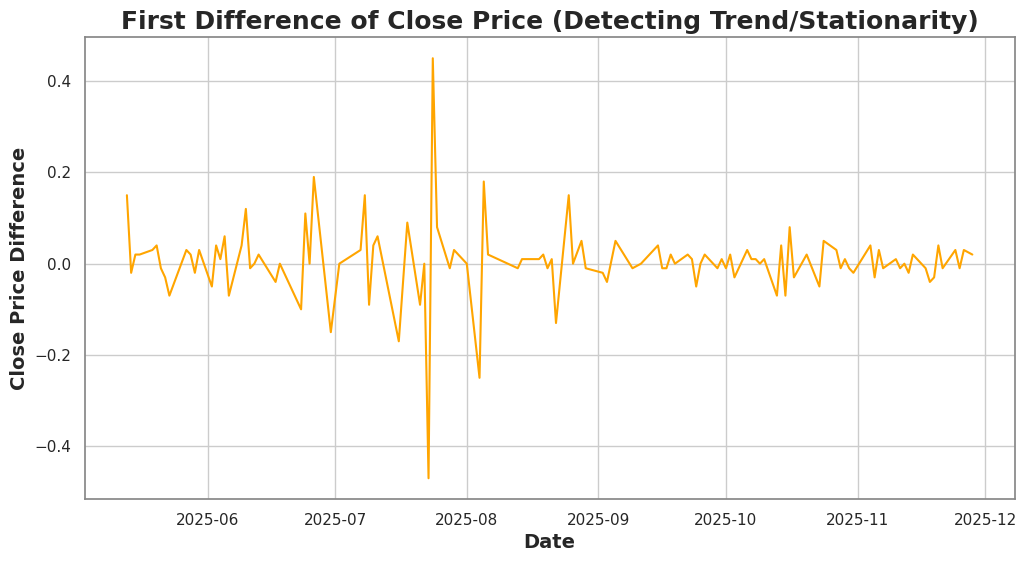

In [185]:

# Basic timeseries analysis on 'close' data'

# Use the DataFrame index as x-axis if 'end_period' is missing to prevent KeyError

date_col = None

if 'end_period' in plot_df.columns:
    date_col = plot_df['end_period']
else:
    date_col = plot_df.index

# Plot the 'close' price timeseries
plt.figure(figsize=(12,6))
plt.plot(date_col, plot_df['close'], marker='o')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Market Close Price Over Time')
plt.grid(True)
plt.show()

# Summary statistics for 'close'
print("Summary statistics for 'close':")
print(plot_df['close'].describe())

# Calculate and plot moving averages
plot_df['close_ma7'] = plot_df['close'].rolling(window=7).mean()
plot_df['close_ma30'] = plot_df['close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(date_col, plot_df['close'], label='Close', alpha=0.7)
plt.plot(date_col, plot_df['close_ma7'], label='7-day MA', linestyle='--')
plt.plot(date_col, plot_df['close_ma30'], label='30-day MA', linestyle='-.')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price with 7-day and 30-day Moving Averages')
plt.legend()
plt.grid(True)
plt.show()

# Check for autocorrelation in the series
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(8,6))
autocorrelation_plot(plot_df['close'].dropna())
plt.title('Autocorrelation of Close Price')
plt.show()

# Check for seasonality or trend (using simple differencing)
plot_df['close_diff'] = plot_df['close'].diff()

plt.figure(figsize=(12,6))
plt.plot(date_col, plot_df['close_diff'], label='First Difference', color='orange')
plt.xlabel('Date')
plt.ylabel('Close Price Difference')
plt.title('First Difference of Close Price (Detecting Trend/Stationarity)')
plt.grid(True)
plt.show()



In [186]:
# Create predictive features using 'sp500_close' and 'spy_volume'
mldata = merged_df.copy()

# Always use previous day (lagged) data for features predicting today's close
# Lag the close as well, so only previous close is available to the model

mldata['close_lag1'] = mldata['close'].shift(1)
mldata['sp500_close_lag1'] = mldata['sp500_close'].shift(1)
mldata['spy_volume_lag1'] = mldata['spy_volume'].shift(1)

mldata['sp500_close_ret1_lag1'] = mldata['sp500_close'].pct_change(1).shift(1)
mldata['sp500_close_ret7_lag1'] = mldata['sp500_close'].pct_change(7).shift(1)
mldata['spy_volume_ret1_lag1'] = mldata['spy_volume'].pct_change(1).shift(1)

mldata['sp500_close_ma7_lag1'] = mldata['sp500_close'].rolling(window=7).mean().shift(1)
mldata['sp500_close_ma30_lag1'] = mldata['sp500_close'].rolling(window=30).mean().shift(1)
mldata['spy_volume_ma7_lag1'] = mldata['spy_volume'].rolling(window=7).mean().shift(1)

# Relative features: always use previous day info
mldata['close_spread_vs_sp500_lag1'] = (
    mldata['close_lag1'] - mldata['sp500_close_lag1'] / 10000
)
mldata['close_ratio_sp500_lag1'] = (
    mldata['close_lag1'] / (mldata['sp500_close_lag1'] / 10000)
)

# Interaction term (previous day's returns)
mldata['price_vol_interact_lag1'] = mldata['sp500_close_ret1_lag1'] * mldata['spy_volume_ret1_lag1']


In [187]:
mldata.head()

,end_period,open_interest,close,volume,sp500_close,spy_volume,close_lag1,sp500_close_lag1,spy_volume_lag1,sp500_close_ret1_lag1,sp500_close_ret7_lag1,spy_volume_ret1_lag1,sp500_close_ma7_lag1,sp500_close_ma30_lag1,spy_volume_ma7_lag1,close_spread_vs_sp500_lag1,close_ratio_sp500_lag1,price_vol_interact_lag1
2,2025-05-12,354,0.39,245,5844.189941,6.014580e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-05-13,428,0.54,74,5886.549805,5.516290e+09,0.39,5844.189941,6.014580e+09,NaN,NaN,NaN,NaN,NaN,NaN,-0.194419,0.667329,NaN
4,2025-05-14,853,0.52,472,5892.580078,5.233450e+09,0.54,5886.549805,5.516290e+09,0.007248,NaN,-0.082847,NaN,NaN,NaN,-0.048655,0.917346,-0.000600
5,2025-05-15,2410,0.54,1855,5916.930176,4.991290e+09,0.52,5892.580078,5.233450e+09,0.001024,NaN,-0.051274,NaN,NaN,NaN,-0.069258,0.882466,-0.000053
6,2025-05-16,2847,0.56,537,5958.379883,4.850850e+09,0.54,5916.930176,4.991290e+09,0.004132,NaN,-0.046272,NaN,NaN,NaN,-0.051693,0.912635,-0.000191


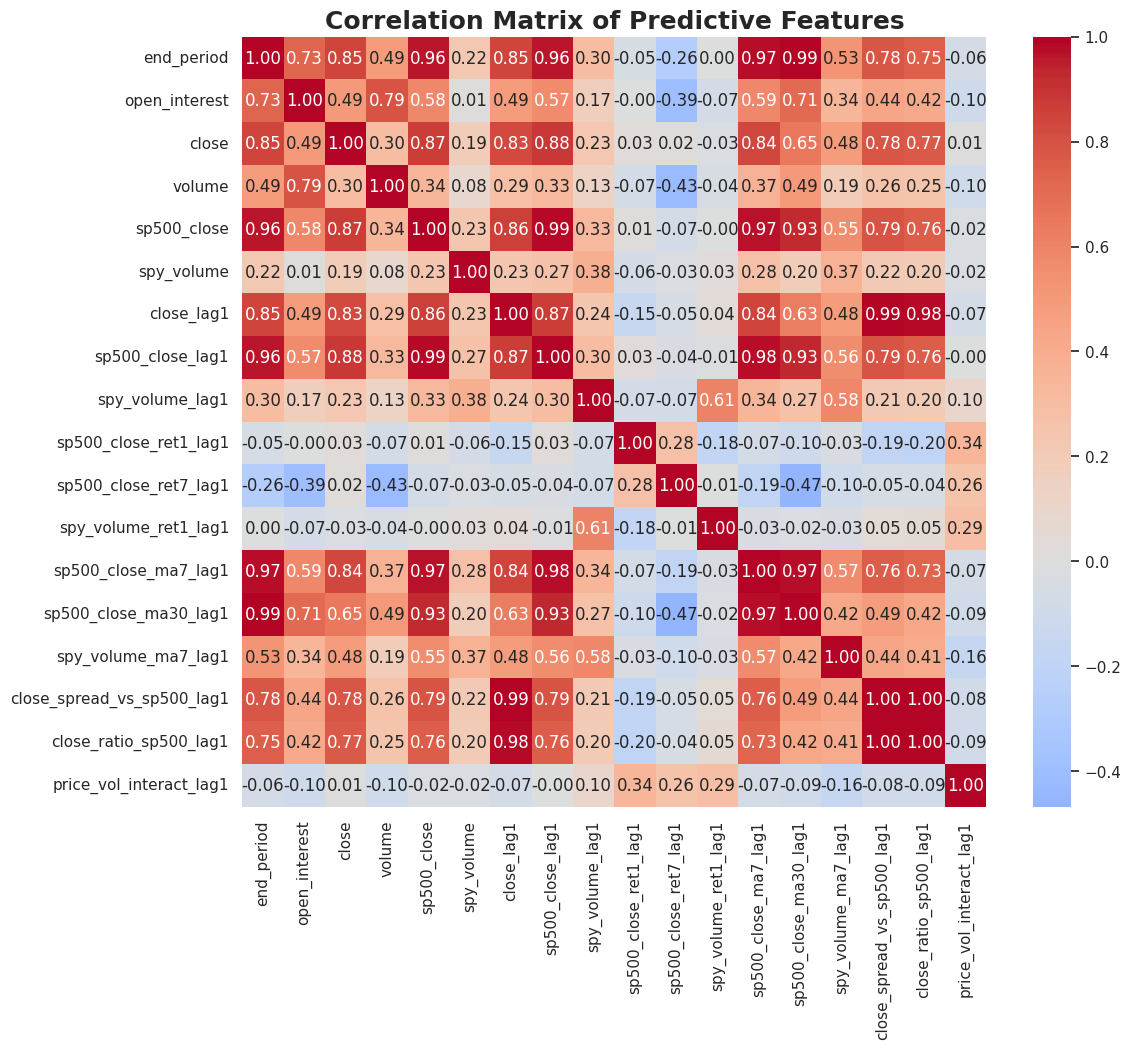

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation matrix
corr_matrix = mldata.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Predictive Features')
plt.show()


Linear regression coefficients:

close_lag1                     -0.925705
sp500_close_lag1                0.000381
spy_volume_lag1                -0.000000
sp500_close_ret1_lag1           0.966023
spy_volume_ret1_lag1           -0.030693
sp500_close_ma30_lag1           0.000057
spy_volume_ma7_lag1             0.000000
close_spread_vs_sp500_lag1     -0.925705
close_ratio_sp500_lag1          1.303374
price_vol_interact_lag1         5.805044

Intercept: -2.791682

R^2: 0.5137
RMSE: 0.0657


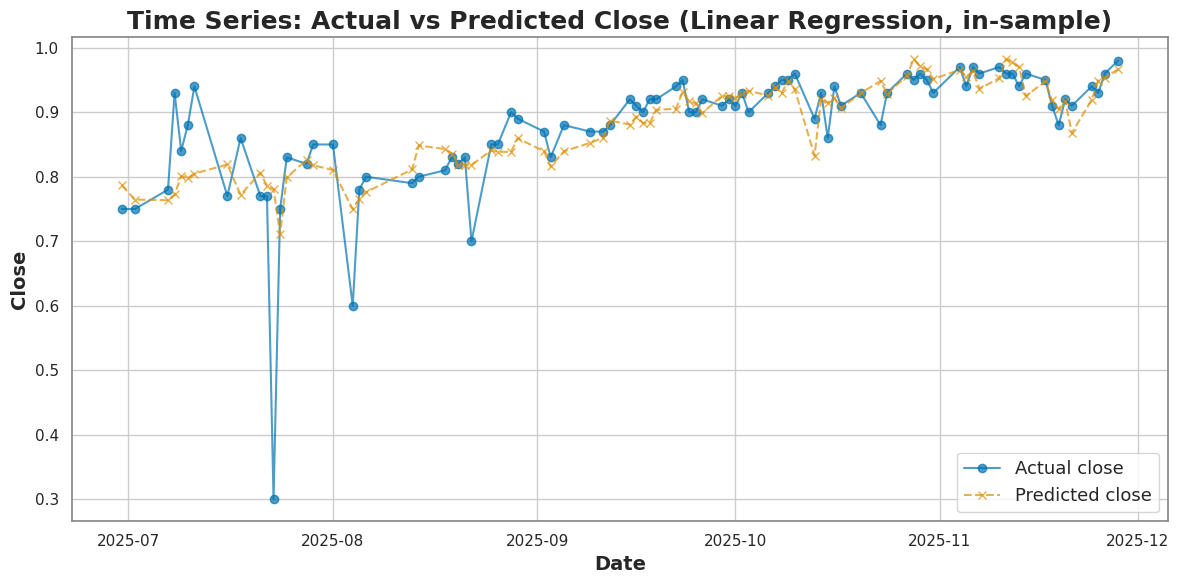

In [189]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Drop NA rows so features and target align
mlreg = mldata.dropna(subset=[
    'close', 'close_lag1', 'sp500_close_lag1', 'spy_volume_lag1',
    'sp500_close_ret1_lag1', 'sp500_close_ret7_lag1', 'spy_volume_ret1_lag1',
    'sp500_close_ma7_lag1', 'sp500_close_ma30_lag1', 'spy_volume_ma7_lag1',
    'close_spread_vs_sp500_lag1', 'close_ratio_sp500_lag1', 'price_vol_interact_lag1'
]).copy()

# Pick some features
feature_cols = [
    'close_lag1', 'sp500_close_lag1', 'spy_volume_lag1',
    'sp500_close_ret1_lag1', 'spy_volume_ret1_lag1',
    'sp500_close_ma30_lag1', 'spy_volume_ma7_lag1',
    'close_spread_vs_sp500_lag1', 'close_ratio_sp500_lag1',
    'price_vol_interact_lag1'
]
X = mlreg[feature_cols]
y = mlreg['close']

lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)

# Print coefficients
print("Linear regression coefficients:\n")
for name, coef in zip(feature_cols, lr.coef_):
    print(f"{name:30} {coef: .6f}")
print(f"\nIntercept: {lr.intercept_:.6f}")

# Regression stats
print(f"\nR^2: {r2_score(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")

# Plot predicted vs actual timeseries
plt.figure(figsize=(12,6))
if 'end_period' in mlreg.columns:
    xvals = mlreg['end_period']
elif 'date' in mlreg.columns:
    xvals = mlreg['date']
else:
    xvals = mlreg.index
plt.plot(xvals, y, label='Actual close', marker='o', linestyle='-', alpha=0.7)
plt.plot(xvals, y_pred, label='Predicted close', marker='x', linestyle='--', alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Time Series: Actual vs Predicted Close (Linear Regression, in-sample)")
plt.legend()
plt.tight_layout()
plt.show()



# Market 2 - POLYMARKET
url = "https://gamma-api.polymarket.com/events/slug/what-price-will-bitcoin-hit-november-24-30"


In [25]:
import requests
import pandas as pd
import ast

url = "https://gamma-api.polymarket.com/events/slug/what-price-will-bitcoin-hit-november-24-30"
response = requests.get(url)
markets = response.json().get('markets', [])

if markets:
    # Store all markets in a DataFrame, extract Yes price using outcomes/outcomePrices and also get a clobTokenId if present
    def get_yes_price(market):
        outcomes = market.get('outcomes')
        outcome_prices = market.get('outcomePrices')
        yes_price = None
        if outcomes and outcome_prices:
            # Handle if they're Python string representations of lists
            if isinstance(outcomes, str):
                try:
                    outcomes_list = ast.literal_eval(outcomes)
                except Exception:
                    outcomes_list = []
            else:
                outcomes_list = outcomes
            if isinstance(outcome_prices, str):
                try:
                    outcome_prices_list = ast.literal_eval(outcome_prices)
                except Exception:
                    outcome_prices_list = []
            else:
                outcome_prices_list = outcome_prices
            if "Yes" in outcomes_list:
                i = outcomes_list.index("Yes")
                if isinstance(outcome_prices_list, list) and len(outcome_prices_list) > i:
                    try:
                        yes_price = float(outcome_prices_list[i])
                    except Exception:
                        yes_price = None
        return yes_price

    def get_yes_clob_token_id(market):
        """
        Find the clobTokenId for the 'Yes' outcome, if available.
        """
        outcomes = market.get('outcomes')
        clob_token_ids = market.get('clobTokenIds')
        if outcomes and clob_token_ids:
            # List-style normalization (may be a str)
            if isinstance(outcomes, str):
                try:
                    outcomes = ast.literal_eval(outcomes)
                except Exception:
                    outcomes = []
            if isinstance(clob_token_ids, str):
                try:
                    clob_token_ids = ast.literal_eval(clob_token_ids)
                except Exception:
                    clob_token_ids = []
            if "Yes" in outcomes:
                idx = outcomes.index("Yes")
                if isinstance(clob_token_ids, list) and len(clob_token_ids) > idx:
                    return clob_token_ids[idx]
        return None

    def get_float(val):
        try:
            return float(val)
        except Exception:
            return None

    df_all_markets = pd.DataFrame([
        {
            'Id': market.get('id', 'N/A'),
            'Title': market.get('question', 'N/A'),
            'Volume': get_float(market.get('volume', 'N/A')),
            'Yes_Price': get_yes_price(market),
            'Yes_clobTokenId': get_yes_clob_token_id(market)
        }
        for market in markets
    ])
    # Drop any rows with missing volume for reliable sorting (optional, can be omitted)
    df_all_markets = df_all_markets.dropna(subset=["Volume"])
    # Remove all rows where Yes_Price >= 1
    df_all_markets = df_all_markets[df_all_markets['Yes_Price'] < 1]
    # Sort by volume descending
    df_all_markets = df_all_markets.sort_values('Volume', ascending=False).reset_index(drop=True)
    df_all_markets
else:
    print("No markets found.")

In [26]:
df_all_markets

,Id,Title,Volume,Yes_Price,Yes_clobTokenId
0,699721,"Will Bitcoin reach $94,000 November 24-30?",424435.870628,0.0700,2879694418589369629770714827773082566230790446...
1,699720,"Will Bitcoin reach $96,000 November 24-30?",337745.583712,0.0135,7561025881632563100179673648503181748599257429...
2,699718,"Will Bitcoin reach $100,000 November 24-30?",266351.311588,0.0065,5757279480816911620023491366110767135329713126...
3,699726,"Will Bitcoin dip to $84,000 November 24-30?",197782.417919,0.0105,1071312394615133445401181496028848815664883674...
4,699729,"Will Bitcoin dip to $82,000 November 24-30?",136496.735722,0.0025,1039406328753857660467272318086833142562896915...
5,699719,"Will Bitcoin reach $98,000 November 24-30?",127131.971330,0.0075,1105669950364718363093039329546062178127941582...
6,699730,"Will Bitcoin dip to $80,000 November 24-30?",90800.255620,0.0020,1142038113152927486818033130278054191700621737...
7,699736,"Will Bitcoin dip to $78,000 November 24-30?",76580.616559,0.0020,8697844909825386512006374245930411562848243695...
8,699745,"Will Bitcoin dip to $74,000 November 24-30?",53166.844974,0.0010,1139257804888602146804681535025114548661678460...
9,699747,"Will Bitcoin dip to $72,000 November 24-30?",42107.252082,0.0025,9285089039950338666172775550635452195659514934...


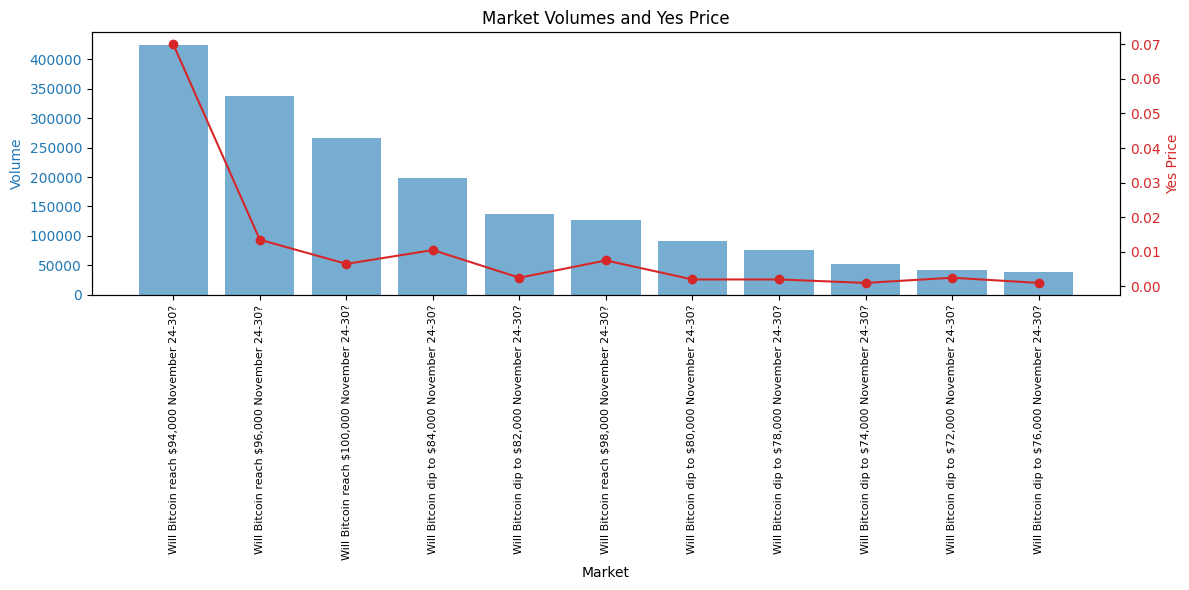

In [27]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Market')
ax1.set_ylabel('Volume', color=color)
ax1.bar(df_all_markets['Title'], df_all_markets['Volume'], color=color, alpha=0.6, label='Volume')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(len(df_all_markets)))
ax1.set_xticklabels(df_all_markets['Title'], rotation=90, ha='center', fontsize=8)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Yes Price', color=color)
ax2.plot(df_all_markets['Title'], df_all_markets['Yes_Price'], color=color, marker='o', label='Yes Price')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Market Volumes and Yes Price')
fig.tight_layout()
plt.show()


In [28]:
df_all_markets.iloc[0]['Yes_clobTokenId']

'28796944185893696297707148277730825662307904469781602827633763943335296574544'

In [29]:
import requests

def get_hourly_median_prices(market_id):
    url = f"https://clob.polymarket.com/prices-history?market={market_id}&startTs=0&interval=max"
    response = requests.get(url)
    
    if response.status_code != 200:
        print(f"Failed to fetch data: HTTP {response.status_code}")
        return None

    data = response.json()
    if data and 'history' in data:
        df_history = pd.DataFrame(data['history'])
        # Convert the 't' (timestamp) column to human-readable datetime
        df_history['time'] = pd.to_datetime(df_history['t'], unit='s')

        # Create date and hour columns
        df_history['date'] = df_history['time'].dt.date
        df_history['hour'] = df_history['time'].dt.hour

        # Group by date and hour, compute median price in each hour
        grouped = df_history.groupby(['date', 'hour'])['p'].median().reset_index()

        # Create a new datetime column for the start of each hour
        grouped['datetime'] = pd.to_datetime(grouped['date'].astype(str) + ' ' + grouped['hour'].astype(str) + ':00:00')

        # Keep only necessary columns for clarity
        grouped = grouped[['datetime', 'p']]
        grouped = grouped.rename(columns={'datetime': 'date', 'p': 'median_price_in_hour'})

        return grouped
    else:
        print("No history data found.")
        return None

# Get hourly median prices for all markets and merge by time
from functools import reduce

all_market_dfs = []
market_titles = df_all_markets['Title']
market_ids = df_all_markets['Yes_clobTokenId']

for title, market_id in zip(market_titles, market_ids):
    df_market = get_hourly_median_prices(market_id)
    if df_market is not None:
        # Rename price column to reflect the market's title
        clean_title = title.strip().replace('\n', '').replace(' ', '_').replace('?', '').replace(':', '').replace('/', '_')[:30]
        df_market = df_market.rename(columns={'median_price_in_hour': f'median_price_{clean_title}'})
        all_market_dfs.append(df_market)

# Merge all on 'date' (which is the datetime per hour)
if all_market_dfs:
    df_merged = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), all_market_dfs)
    df_merged = df_merged.sort_values('date').reset_index(drop=True)
else:
    df_merged = pd.DataFrame()

# df_merged now contains one row per hour, each market's question as a column of median prices


In [30]:
import re

df_merged_numeric = df_merged.copy()
new_column_names = {}

for col in df_merged_numeric.columns:
    if col != 'date':
        # Remove any non-numeric characters and convert to float
        df_merged_numeric[col] = pd.to_numeric(df_merged_numeric[col], errors='coerce')
        # Extract just the number (possibly with decimal) from the column name
        match = re.search(r'([0-9]+(?:\.[0-9]+)?)', col)
        if match:
            new_column_names[col] = match.group(1)
        else:
            new_column_names[col] = col
    else:
        new_column_names[col] = col

df_merged_numeric = df_merged_numeric.rename(columns=new_column_names)
df_merged_numeric

,date,94,96,100,84,82,98,80,78,74,72,76
0,2025-11-24 05:00:00,0.5000,0.50000,0.50000,0.5000,0.50000,0.50000,0.50000,0.5000,0.5000,0.50000,0.5000
1,2025-11-24 06:00:00,0.2550,0.18000,0.10000,0.5000,0.50000,0.12500,0.50000,0.5000,0.5000,0.50000,0.5000
2,2025-11-24 07:00:00,0.2500,0.14750,0.06000,0.6125,0.40750,0.09000,0.26500,0.1500,0.0650,0.05000,0.1100
3,2025-11-24 08:00:00,0.2350,0.13500,0.05750,0.6200,0.41000,0.09000,0.26000,0.1400,0.0650,0.05000,0.1050
4,2025-11-24 09:00:00,0.2125,0.12250,0.04250,0.6950,0.47500,0.08250,0.29750,0.1625,0.0725,0.05250,0.1175
...,...,...,...,...,...,...,...,...,...,...,...,...
132,2025-11-29 17:00:00,0.0675,0.01500,0.00250,0.0100,0.00575,0.01200,0.00200,0.0020,0.0010,0.00300,0.0010
133,2025-11-29 18:00:00,0.0525,0.01225,0.00250,0.0115,0.00600,0.00950,0.00200,0.0020,0.0010,0.00275,0.0010
134,2025-11-29 19:00:00,0.0700,0.01750,0.00450,0.0115,0.00500,0.00950,0.00225,0.0020,0.0010,0.00250,0.0015
135,2025-11-29 20:00:00,0.0650,0.01800,0.00475,0.0100,0.00500,0.00825,0.00300,0.0020,0.0010,0.00250,0.0015


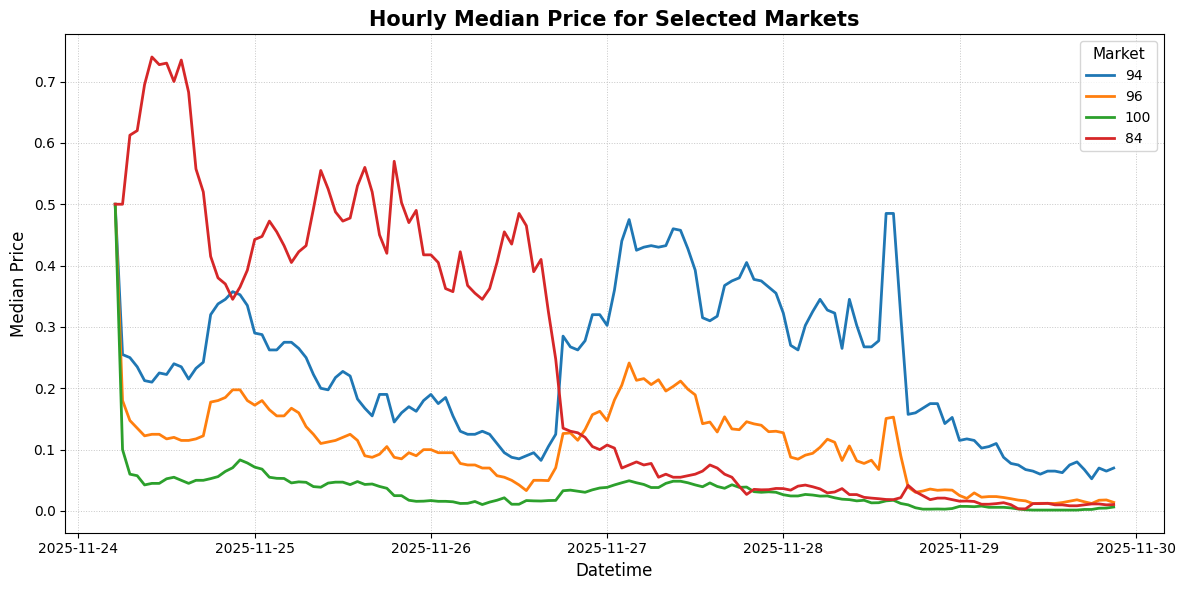

Only first 4 markets plotted for clarity. (Total markets: 11)


In [31]:
import matplotlib.pyplot as plt

if not df_merged_numeric.empty:
    # Let user select just a few markets to keep graph readable if many markets are present
    cols_to_plot = [col for col in df_merged_numeric.columns if col != "date"]
    max_curves = 4  # You can change this number, or make it interactive.
    to_show = cols_to_plot[:max_curves]
    colors = plt.cm.tab10.colors

    plt.figure(figsize=(12, 6))
    for i, col in enumerate(to_show):
        plt.plot(df_merged_numeric['date'], df_merged_numeric[col], label=col, color=colors[i % len(colors)], linewidth=2)
    plt.xlabel("Datetime", fontsize=12)
    plt.ylabel("Median Price", fontsize=12)
    plt.title("Hourly Median Price for Selected Markets", fontsize=15, weight='bold')
    plt.legend(title="Market", fontsize=10, title_fontsize=11)
    plt.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
    plt.tight_layout()
    plt.show()

    if len(cols_to_plot) > max_curves:
        print(f"Only first {max_curves} markets plotted for clarity. (Total markets: {len(cols_to_plot)})")

else:
    print("No data to plot.")


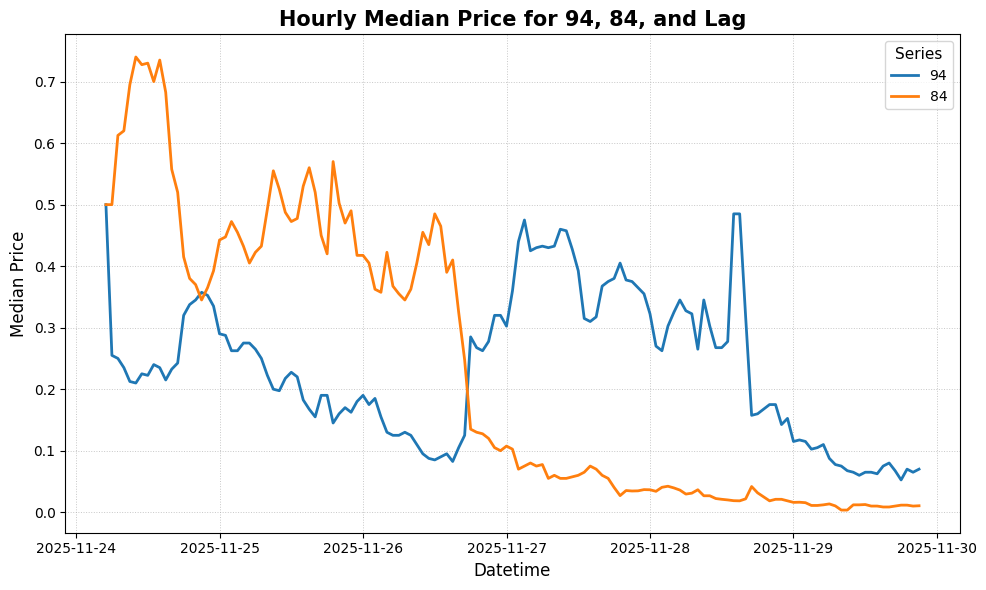

In [32]:
# Plot only '94', '84', and their lagged value (if present)

import matplotlib.pyplot as plt

columns_to_plot = []
if "94" in df_merged_numeric.columns:
    columns_to_plot.append("94")
if "84" in df_merged_numeric.columns:
    columns_to_plot.append("84")
# Look for possible lag columns; name them generically
lag_candidates = [col for col in df_merged_numeric.columns if "lag" in col]
if lag_candidates:
    columns_to_plot.append(lag_candidates[0])

if not df_merged_numeric.empty and columns_to_plot:
    plt.figure(figsize=(10, 6))
    colors = plt.cm.tab10.colors
    for i, col in enumerate(columns_to_plot):
        plt.plot(df_merged_numeric["date"], df_merged_numeric[col], label=col, color=colors[i % len(colors)], linewidth=2)
    plt.xlabel("Datetime", fontsize=12)
    plt.ylabel("Median Price", fontsize=12)
    plt.title("Hourly Median Price for 94, 84, and Lag", fontsize=15, weight='bold')
    plt.legend(title="Series", fontsize=10, title_fontsize=11)
    plt.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for columns: ['94', '84', 'lag']")


In [33]:
import yfinance as yf

if not df_merged_numeric.empty:
    df_merged_numeric['date'] = pd.to_datetime(df_merged_numeric['date'])

    start = df_merged_numeric['date'].min()
    end = df_merged_numeric['date'].max()

    btc = yf.download("BTC-USD", start=start, end=end + pd.Timedelta(hours=1), interval="60m")
    if btc.index.tz is not None:
        btc.index = btc.index.tz_convert(None)
    btc = btc[['Close']].rename(columns={"Close": "btc_usd_close"}).reset_index()
    btc.columns = ["date", "btc_usd_close"]

    df_merged_numeric = pd.merge_asof(
        df_merged_numeric.sort_values("date"),
        btc.sort_values("date"),
        on="date",
        direction="backward"
    )
    print(df_merged_numeric[['date', 'btc_usd_close']].head())
else:
    print("No df_merged_numeric data to add Bitcoin price.")


C:\Users\jmani\AppData\Local\Temp\ipykernel_16396\3584502069.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start=start, end=end + pd.Timedelta(hours=1), interval="60m")
[*********************100%***********************]  1 of 1 completed

                 date  btc_usd_close
0 2025-11-24 05:00:00   87376.507812
1 2025-11-24 06:00:00   86920.609375
2 2025-11-24 07:00:00   86977.445312
3 2025-11-24 08:00:00   86959.367188
4 2025-11-24 09:00:00   85968.671875


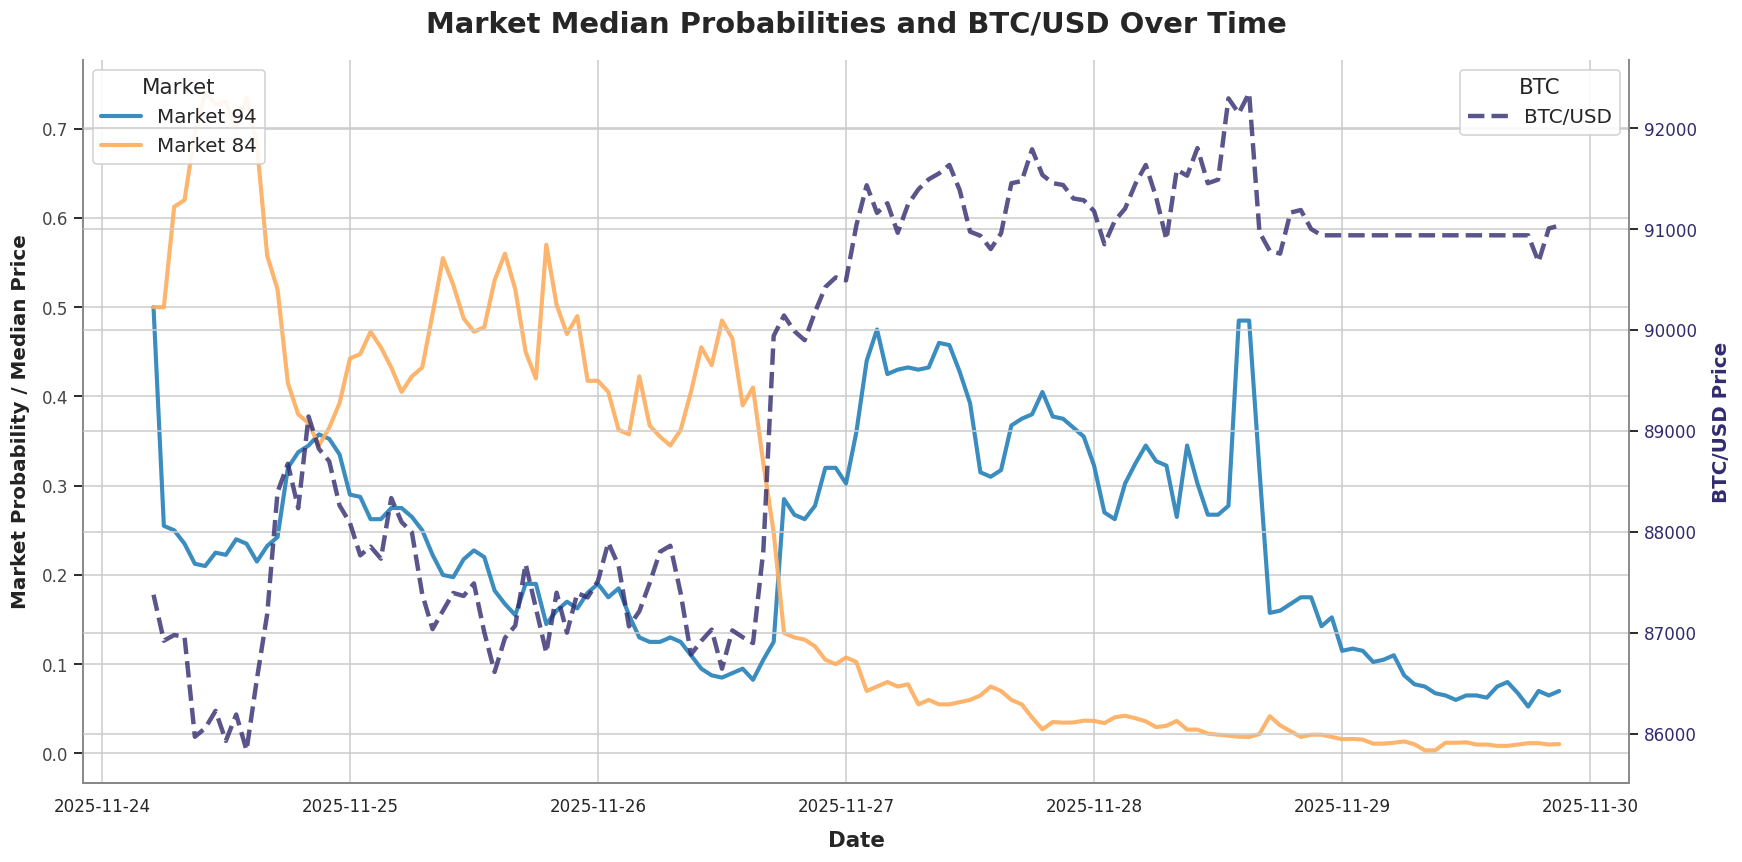

In [34]:
import matplotlib.pyplot as plt

# Use seaborn for better plot aesthetics
import seaborn as sns
sns.set_theme(style="whitegrid", font="DejaVu Sans", palette="colorblind", rc={
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'axes.labelsize': 14,
    'axes.labelweight': 'semibold',
    'legend.fontsize': 13,
    'legend.title_fontsize': 14,
    'axes.edgecolor': '#888'
})

btc_col = "btc_usd_close" if "btc_usd_close" in df_merged_numeric.columns else None
price_cols = [col for col in df_merged_numeric.columns if col not in ("date", btc_col) and (col == "84" or col == "94")]

# Define more attractive colors for the two series
market_color_map = {
    "94": "#2b83ba",   # blue-green
    "84": "#fdae61",   # orange
}
btc_color = "#312b6e"  # deep purple for BTC

if btc_col and price_cols:
    fig, ax1 = plt.subplots(figsize=(16, 8), dpi=110)

    # Plot 84 & 94 market prices
    for col in price_cols:
        color = market_color_map.get(col, None)
        ax1.plot(df_merged_numeric["date"], df_merged_numeric[col], 
                 label=f"Market {col}", 
                 linewidth=2.7, 
                 color=color, 
                 alpha=0.92)
    ax1.set_xlabel("Date", fontsize=14, labelpad=10, weight='semibold')
    ax1.set_ylabel("Market Probability / Median Price", color="#222", fontsize=13, labelpad=8)
    ax1.tick_params(axis='y', labelcolor="#444")
    ax1.legend(loc="upper left", fontsize=13, title="Market", frameon=True, fancybox=True, framealpha=0.9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # BTC price on right y-axis
    ax2 = ax1.twinx()
    ax2.plot(df_merged_numeric["date"], df_merged_numeric[btc_col], 
             label="BTC/USD", 
             color=btc_color, 
             linewidth=2.9, 
             linestyle="--", 
             alpha=0.8
            )
    ax2.set_ylabel("BTC/USD Price", color=btc_color, fontsize=13, labelpad=10)
    ax2.tick_params(axis='y', labelcolor=btc_color)
    ax2.legend(loc="upper right", fontsize=13, title="BTC", frameon=True, fancybox=True, framealpha=0.9)
    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_alpha(0.22)

    plt.title("Market Median Probabilities and BTC/USD Over Time", fontsize=19, weight="bold", pad=18)
    plt.tight_layout()
    plt.show()

elif price_cols:
    plt.figure(figsize=(16, 7), dpi=110)
    for col in price_cols:
        color = market_color_map.get(col, None)
        plt.plot(df_merged_numeric["date"], df_merged_numeric[col], label=f"Market {col}", linewidth=2.8, color=color, alpha=1)
    plt.xlabel("Date", fontsize=14, labelpad=10)
    plt.ylabel("Market Probability / Median Price", fontsize=13, labelpad=7)
    plt.title("84, 94 Market Median Probabilities Over Time", fontsize=18, weight='bold', pad=15)
    plt.legend(fontsize=13, frameon=True, fancybox=True, framealpha=0.9)
    sns.despine()
    plt.tight_layout()
    plt.show()

elif btc_col:
    plt.figure(figsize=(16, 7), dpi=110)
    plt.plot(df_merged_numeric["date"], df_merged_numeric[btc_col], color=btc_color, linewidth=2.8, label="BTC/USD Price", linestyle="--")
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("BTC/USD Price", fontsize=13)
    plt.title("BTC/USD Price Over Time", fontsize=18, weight="bold", pad=15)
    plt.legend(fontsize=13, frameon=True, fancybox=True, framealpha=0.9)
    sns.despine()
    plt.tight_layout()
    plt.show()

else:
    print("No meaningful columns (BTC or 84/94 market probabilities) to plot.")

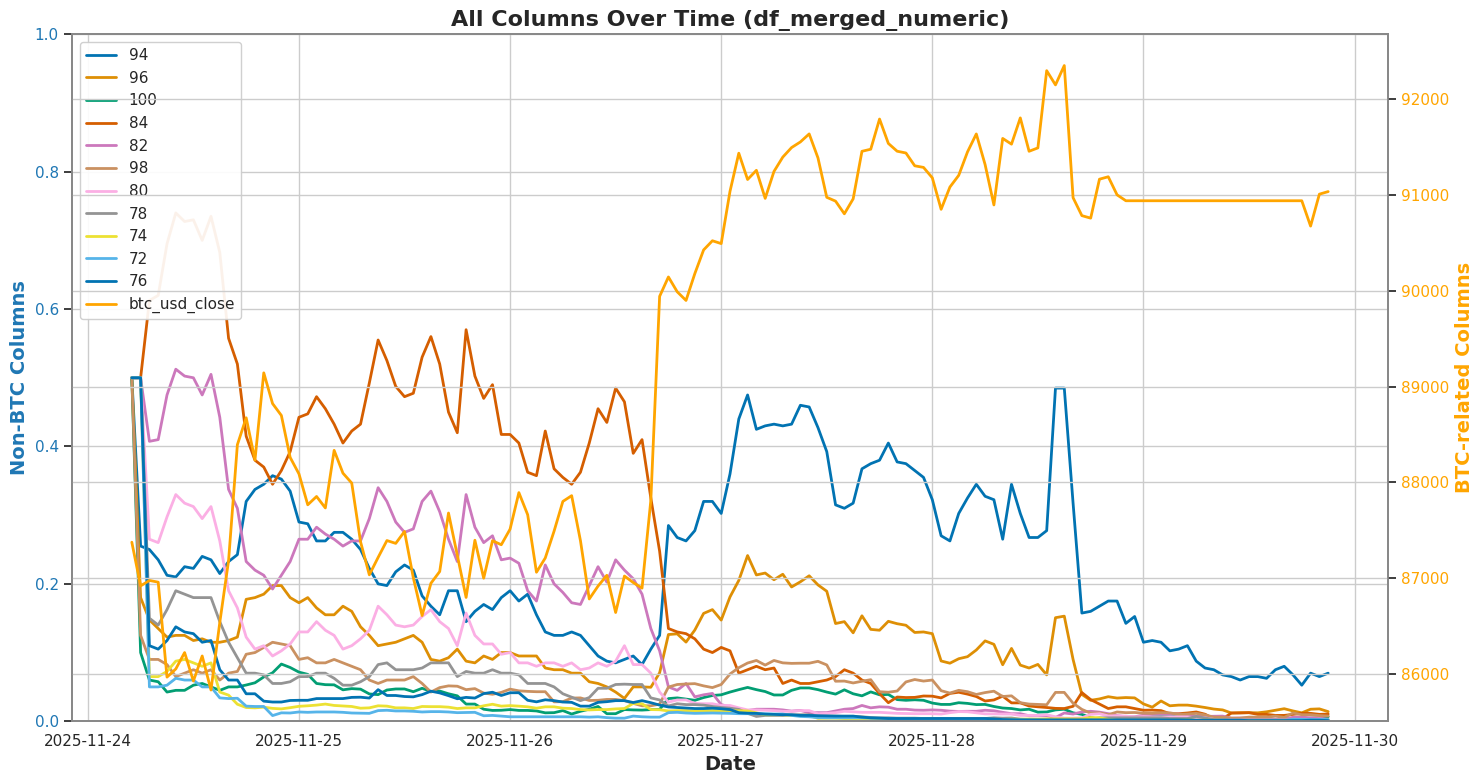

In [35]:
# Plot all columns in df_merged_numeric over time

plot_df = df_merged_numeric.copy()

fig, ax1 = plt.subplots(figsize=(15, 8))

y1_cols = []
y2_cols = []

# Decide which columns to plot on the left and right y-axis
for col in plot_df.columns:
    # Skip 'date' for plotting
    if col == "date":
        continue
    # If column name suggests a BTC price, use right y-axis
    if "btc" in col.lower() or "bitcoin" in col.lower():
        y2_cols.append(col)
    else:
        y1_cols.append(col)

# Plot all non-BTC columns (likely probabilities and others) on left y-axis
for col in y1_cols:
    ax1.plot(plot_df["date"], plot_df[col], label=col, linewidth=2)
ax1.set_xlabel("Date")
ax1.set_ylabel("Non-BTC Columns", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Optionally, set y-limits if you want to force probabilities on 0-1 scale
if any(plot_df[col].max() <= 1 and plot_df[col].min() >= 0 for col in y1_cols):
    ax1.set_ylim(0, 1)

# Plot all BTC-related columns on right y-axis
ax2 = ax1.twinx()
for col in y2_cols:
    # Assign color based on number of btc columns for readability
    color = "orange" if "close" in col and ("usd" in col or "btc" in col) else None
    linestyle = "-" if "lag" not in col else "--"
    ax2.plot(plot_df["date"], plot_df[col], label=col, linewidth=2, color=color, linestyle=linestyle)
ax2.set_ylabel("BTC-related Columns", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Merge legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=11, frameon=True, fancybox=True, framealpha=0.92)

plt.title("All Columns Over Time (df_merged_numeric)", fontsize=16, weight='bold')
fig.tight_layout()
plt.show()


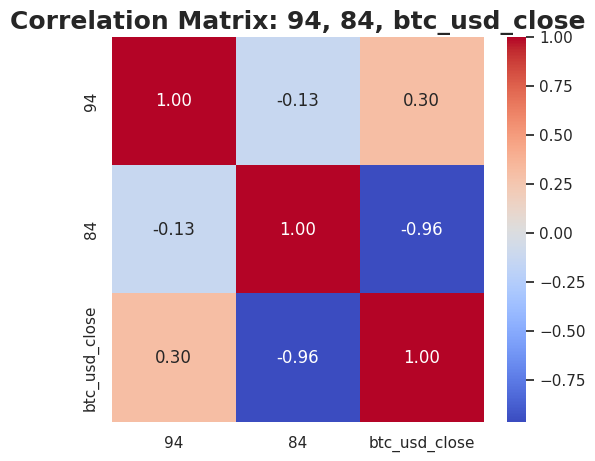

In [36]:
# Correlation plot for columns: 94, 84, btc_usd_close
import seaborn as sns

cols_to_plot = ["94", "84", "btc_usd_close"]
corr = plot_df[cols_to_plot].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: 94, 84, btc_usd_close")
plt.show()


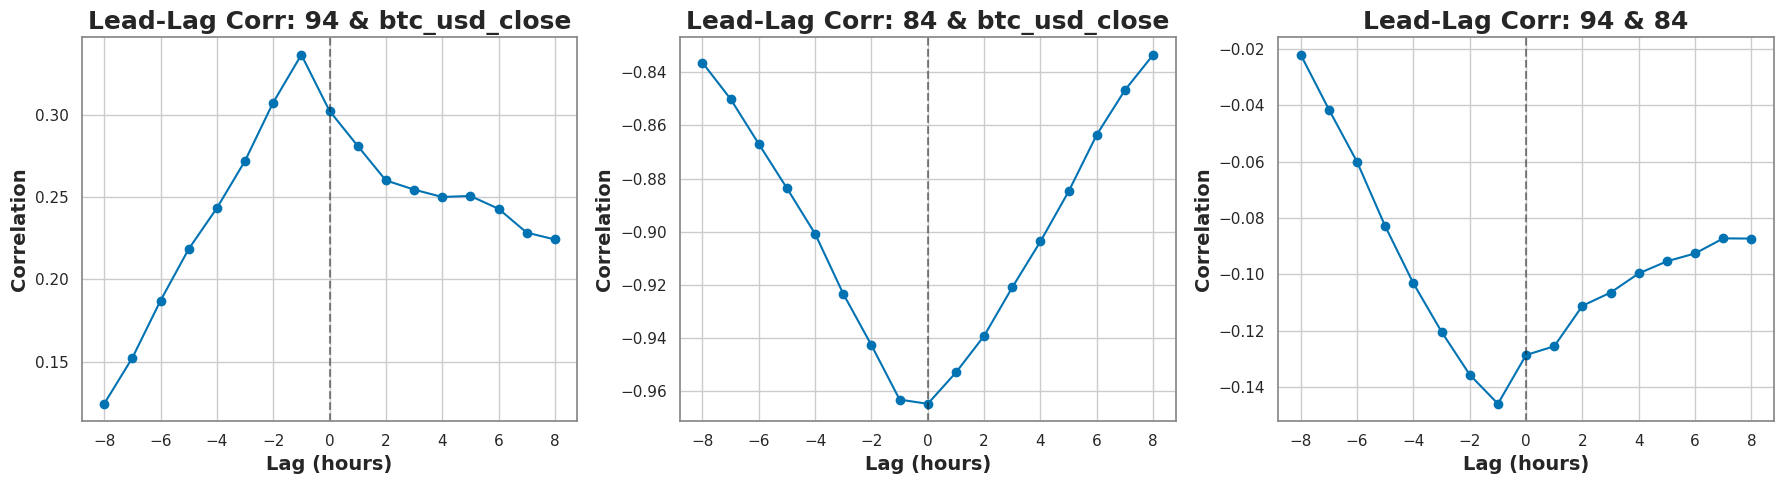

In [37]:
# Lead-lag analysis of 94, 84, and btc_usd_close

import matplotlib.pyplot as plt

lead_lag_cols = ["94", "84", "btc_usd_close"]
max_lag = 8

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,5))

for i, (col1, col2) in enumerate([
    ("94", "btc_usd_close"),
    ("84", "btc_usd_close"),
    ("94", "84"),
]):
    corrs = []
    lags = range(-max_lag, max_lag+1)
    for lag in lags:
        if lag < 0:
            lagged = df_merged_numeric[col2].shift(-lag)
            x = df_merged_numeric[col1]
            y = lagged
        else:
            lagged = df_merged_numeric[col1].shift(lag)
            x = lagged
            y = df_merged_numeric[col2]
        corr = x.corr(y)
        corrs.append(corr)
    axes[i].plot(lags, corrs, marker="o")
    axes[i].axvline(0, color='k', linestyle='--', alpha=0.5)
    axes[i].set_title(f"Lead-Lag Corr: {col1} & {col2}")
    axes[i].set_xlabel("Lag (hours)")
    axes[i].set_ylabel("Correlation")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


=== Random Forest ===
Test predictions (up=1, down=0): [1 0 0 0 0 0 0 0 0]
Actual: [1 0 1 1 0 1 0 0 0]
Accuracy: 0.6666666666666666
Confusion matrix:
 [[5 0]
 [3 1]]
              precision    recall  f1-score   support

           0      0.625     1.000     0.769         5
           1      1.000     0.250     0.400         4

    accuracy                          0.667         9
   macro avg      0.812     0.625     0.585         9
weighted avg      0.792     0.667     0.605         9



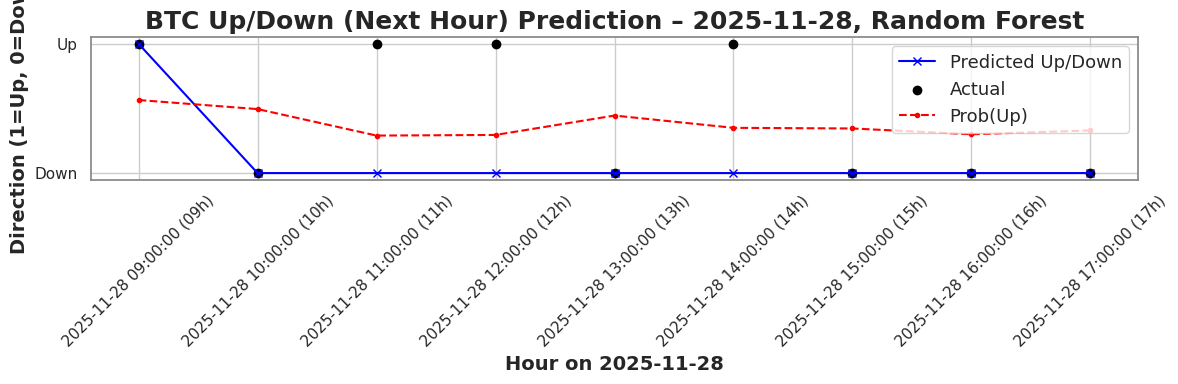


=== Gradient Boosting ===
Test predictions (up=1, down=0): [1 1 0 0 1 0 1 0 1]
Actual: [1 0 1 1 0 1 0 0 0]
Accuracy: 0.2222222222222222
Confusion matrix:
 [[1 4]
 [3 1]]
              precision    recall  f1-score   support

           0      0.250     0.200     0.222         5
           1      0.200     0.250     0.222         4

    accuracy                          0.222         9
   macro avg      0.225     0.225     0.222         9
weighted avg      0.228     0.222     0.222         9



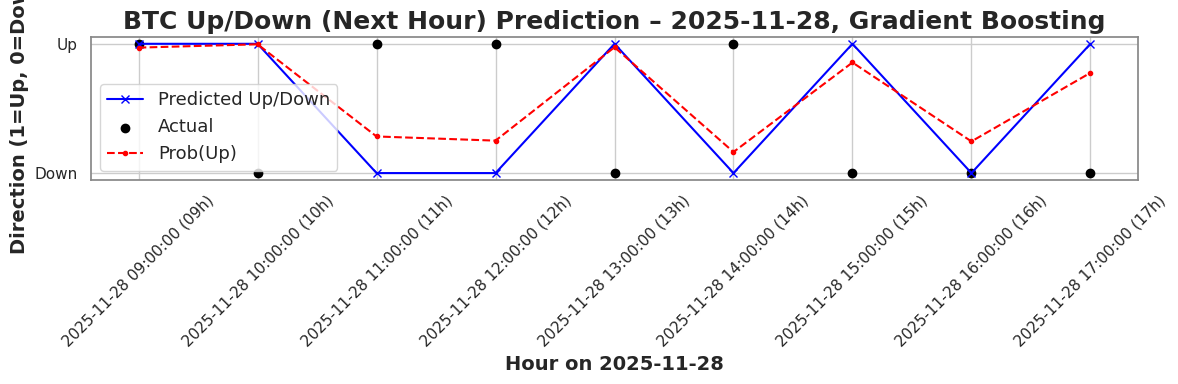

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------- Feature Engineering -----------
df = df_merged_numeric.copy()

# We'll use the previous 3 hours returns and price trends as features
for lag in range(1, 4):
    df[f'btc_close_lag{lag}'] = df['btc_usd_close'].shift(lag)
    df[f'return_lag{lag}'] = df['btc_usd_close'].pct_change(lag)

# Target: 1 if next price is up, else 0
df['target_up'] = (df['btc_usd_close'].shift(-1) > df['btc_usd_close']).astype(int)

# Only use 09-17 hours (as before)
df['hour'] = df['date'].astype(str).str[11:13]
allowed_hours = [f"{h:02d}" for h in range(9, 18)]
df = df[df['hour'].isin(allowed_hours)].reset_index(drop=True)

# Drop NaNs caused by lagging
df = df.dropna().reset_index(drop=True)

# ----------- Train/Test split -----------
# Use all data before 2025-11-28 (excl) for training. Use 28th as test.
split_day = "2025-11-28"

# If date column is datetime, convert split_day to datetime for masking.
if np.issubdtype(df['date'].dtype, np.datetime64):
    split_day_dt = pd.to_datetime(split_day)
    train_idx = df['date'] < split_day_dt
    test_idx = df['date'].dt.strftime("%Y-%m-%d") == split_day
else:
    train_idx = df['date'] < split_day
    test_idx = df['date'].astype(str).str.startswith(split_day)

features = [c for c in df.columns if c not in ['date','hour','btc_usd_close','target_up'] and not c.startswith('_')]

X_train = df.loc[train_idx, features]
y_train = df.loc[train_idx, 'target_up']

X_test = df.loc[test_idx, features]
y_test = df.loc[test_idx, 'target_up']
labels_test = df.loc[test_idx, 'date'].astype(str) + " (" + df.loc[test_idx, 'hour'] + "h)"

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------- Train and Evaluate Models -----------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    if hasattr(clf, "predict_proba"):
        prob_pred = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        prob_pred = None

    print(f"\n=== {name} ===")
    print("Test predictions (up=1, down=0):", y_pred)
    print("Actual:", y_test.values)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))

    plt.figure(figsize=(12, 4))
    plt.plot(labels_test, y_pred, marker="x", label="Predicted Up/Down", color="blue")
    plt.scatter(labels_test, y_test, marker="o", label="Actual", color="black")
    if prob_pred is not None:
        plt.plot(labels_test, prob_pred, marker=".", linestyle="--", label="Prob(Up)", color="red")
    plt.title(f"BTC Up/Down (Next Hour) Prediction – 2025-11-28, {name}")
    plt.xlabel("Hour on 2025-11-28")
    plt.ylabel("Direction (1=Up, 0=Down)")
    plt.xticks(rotation=45)
    plt.yticks([0, 1], ['Down', 'Up'])
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# 3 Fed Decision

https://kalshi.com/markets/kxfeddecision/fed-meeting/kxfeddecision-25dec


In [ ]:
markets_url = f"https://api.elections.kalshi.com/trade-api/v2/markets?series_ticker=KXFEDDECISION&status=open"
markets_response = requests.get(markets_url)
markets_data = markets_response.json()

event_tickers = []
print(f"\nActive markets in KXINXY series:")
for market in reversed(markets_data['markets']):
    event_ticker = market.get('event_ticker')
    ticker = market.get('ticker')
    title = market.get('title')
    volume = market.get('volume')
    liquidity = market.get('liquidity')
    print(f"- Event: {event_ticker}\n  Name: {title}\n  Volume: {volume}\n  Liquidity: {liquidity}\n")
    event_tickers.append(event_ticker)


Active markets in KXINXY series:
- Event: KXFEDDECISION-25DEC
  Name: Will the Federal Reserve Cut rates by >25bps at their December 2025 meeting?
  Volume: 4447259
  Liquidity: 42663805

- Event: KXFEDDECISION-25DEC
  Name: Will the Federal Reserve Cut rates by 25bps at their December 2025 meeting?
  Volume: 5689991
  Liquidity: 22117255

- Event: KXFEDDECISION-25DEC
  Name: Will the Federal Reserve Hike rates by 0bps at their December 2025 meeting?
  Volume: 6548879
  Liquidity: 33604391

- Event: KXFEDDECISION-25DEC
  Name: Will the Federal Reserve Hike rates by 25bps at their December 2025 meeting?
  Volume: 183867
  Liquidity: 109542260

- Event: KXFEDDECISION-25DEC
  Name: Will the Federal Reserve Hike rates by >25bps at their December 2025 meeting?
  Volume: 44374
  Liquidity: 109818979

- Event: KXFEDDECISION-26JAN
  Name: Will the Federal Reserve Cut rates by 25bps at their January 2026 meeting?
  Volume: 6704
  Liquidity: 95359459

- Event: KXFEDDECISION-26JAN
  Name: Will t

In [122]:
markets_url = f"https://api.elections.kalshi.com/trade-api/v2/markets?event_ticker=KXFEDDECISION-25DEC"
markets_response = requests.get(markets_url)
markets_data = markets_response.json()

market_tickers = {}
print(f"\nActive markets in KXINXY series:")
for market in reversed(markets_data['markets']):
    market_ticker = market.get('ticker')
    title = market.get('title')
    volume = market.get('volume')
    liquidity = market.get('liquidity')
    print(f"- Market: {market_ticker}\n  Name: {title}\n  Volume: {volume}\n  Liquidity: {liquidity}\n")
    market_tickers[market_ticker] = title


Active markets in KXINXY series:
- Market: KXFEDDECISION-25DEC-C26
  Name: Will the Federal Reserve Cut rates by >25bps at their December 2025 meeting?
  Volume: 4447259
  Liquidity: 42663805

- Market: KXFEDDECISION-25DEC-C25
  Name: Will the Federal Reserve Cut rates by 25bps at their December 2025 meeting?
  Volume: 5689991
  Liquidity: 22117255

- Market: KXFEDDECISION-25DEC-H0
  Name: Will the Federal Reserve Hike rates by 0bps at their December 2025 meeting?
  Volume: 6548879
  Liquidity: 33604391

- Market: KXFEDDECISION-25DEC-H25
  Name: Will the Federal Reserve Hike rates by 25bps at their December 2025 meeting?
  Volume: 183867
  Liquidity: 109542260

- Market: KXFEDDECISION-25DEC-H26
  Name: Will the Federal Reserve Hike rates by >25bps at their December 2025 meeting?
  Volume: 44374
  Liquidity: 109818979



In [124]:
def simplify_fed_decision_label(title):
    # Cut logic
    if "Cut rates by >25bps" in title:
        return "cut >25"
    elif "Cut rates by 25bps" in title:
        return "cut = 25"
    elif " rates by 0bps" in title:
        return "cut = 0"
    # Hike logic
    elif "Hike rates by >25bps" in title:
        return "hike = 25"
    elif "Hike rates by 25bps" in title:
        return "hike >25"
    else:
        return title

simplified_market_tickers = {k: simplify_fed_decision_label(v) for k, v in market_tickers.items()}
simplified_market_tickers

{'KXFEDDECISION-25DEC-C26': 'cut >25',
 'KXFEDDECISION-25DEC-C25': 'cut = 25',
 'KXFEDDECISION-25DEC-H0': 'cut = 0',
 'KXFEDDECISION-25DEC-H25': 'hike >25',
 'KXFEDDECISION-25DEC-H26': 'hike = 25'}

In [125]:
def get_kalshi_fed_dataframe(ticker, start_date='08/05/2025'):
    df = get_candlestick_data(ticker, start_date)
    def safe_float(val):
        try:
            if val is None:
                return None
            return float(val)
        except (TypeError, ValueError):
            return None

    return pd.DataFrame({
        'end_period': pd.to_datetime(df['end_period_ts'], unit='s').dt.strftime('%m/%d/%Y'),
        'open_interest': df['open_interest'],
        'close': df['price'].apply(lambda x: safe_float(x.get('close_dollars')) if isinstance(x, dict) else None),
        'volume': (
            df['volume']
                if 'volume' in df.columns
                else df['price'].apply(lambda x: safe_float(x.get('volume')) if isinstance(x, dict) else None)
        )
    })


# For each simplified_market_ticker, get dataframe and rename 'close'/'volume'
dfs = []
for ticker, title in simplified_market_tickers.items():
    df = get_kalshi_fed_dataframe(ticker)
    df_renamed = df.rename(columns={
        'close': f"{title}_close",
        'volume': f"{title}_volume"
    })[['end_period', f"{title}_close", f"{title}_volume"]]  # Only keep these for merge
    dfs.append(df_renamed)

from functools import reduce

# Merge all on 'end_period'
from functools import reduce
df_merged = reduce(lambda left, right: pd.merge(left, right, how='outer', on='end_period'), dfs)

df_merged

{'candlesticks': [{'end_period_ts': 1754452800, 'open_interest': 0, 'price': {'close': None, 'high': None, 'low': None, 'max': None, 'mean': None, 'min': None, 'open': None, 'previous': None}, 'volume': 0, 'yes_ask': {'close': 11, 'close_dollars': '0.1100', 'high': 100, 'high_dollars': '1.0000', 'low': 11, 'low_dollars': '0.1100', 'open': 100, 'open_dollars': '1.0000'}, 'yes_bid': {'close': 5, 'close_dollars': '0.0500', 'high': 5, 'high_dollars': '0.0500', 'low': 1, 'low_dollars': '0.0100', 'open': 1, 'open_dollars': '0.0100'}}, {'end_period_ts': 1754539200, 'open_interest': 0, 'price': {'close': None, 'high': None, 'low': None, 'max': None, 'mean': None, 'min': None, 'open': None, 'previous': None}, 'volume': 0, 'yes_ask': {'close': 11, 'close_dollars': '0.1100', 'high': 88, 'high_dollars': '0.8800', 'low': 11, 'low_dollars': '0.1100', 'open': 11, 'open_dollars': '0.1100'}, 'yes_bid': {'close': 5, 'close_dollars': '0.0500', 'high': 5, 'high_dollars': '0.0500', 'low': 0, 'low_dollars':

,end_period,cut >25_close,cut >25_volume,cut = 25_close,cut = 25_volume,cut = 0_close,cut = 0_volume,hike >25_close,hike >25_volume,hike = 25_close,hike = 25_volume
0,08/06/2025,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0.0
1,08/07/2025,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0.0
2,08/08/2025,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0.0
3,08/09/2025,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0.0
4,08/10/2025,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...
111,11/25/2025,0.02,129554,0.84,367861,0.16,459039,0.01,3335,0.01,601.0
112,11/26/2025,0.02,368322,0.82,295035,0.18,594898,0.01,5388,0.01,2262.0
113,11/27/2025,0.02,119415,0.83,150879,0.18,192999,0.01,572,0.01,269.0
114,11/28/2025,0.02,97411,0.87,95859,0.14,131939,0.01,4802,0.01,116.0


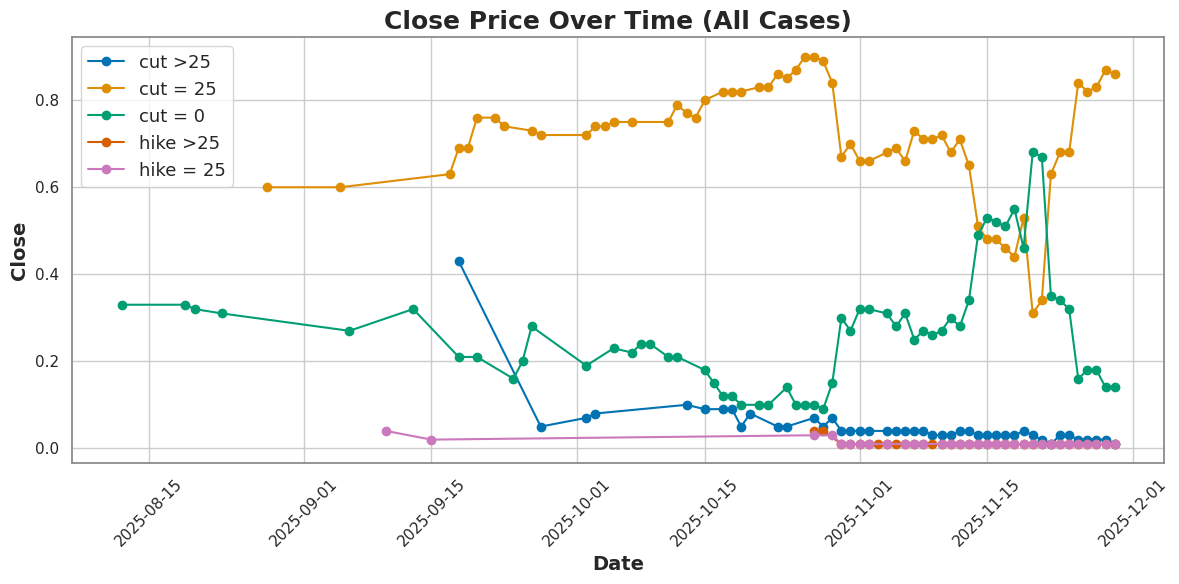

In [126]:
plt.figure(figsize=(12, 6))
cols = [col for col in df_merged.columns if col.endswith('_close')]
for col in cols:
    df_plot = df_merged.dropna(subset=[col])
    plt.plot(pd.to_datetime(df_plot['end_period']), df_plot[col], marker='o', label=col.replace('_close', ''))
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Close Price Over Time (All Cases)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


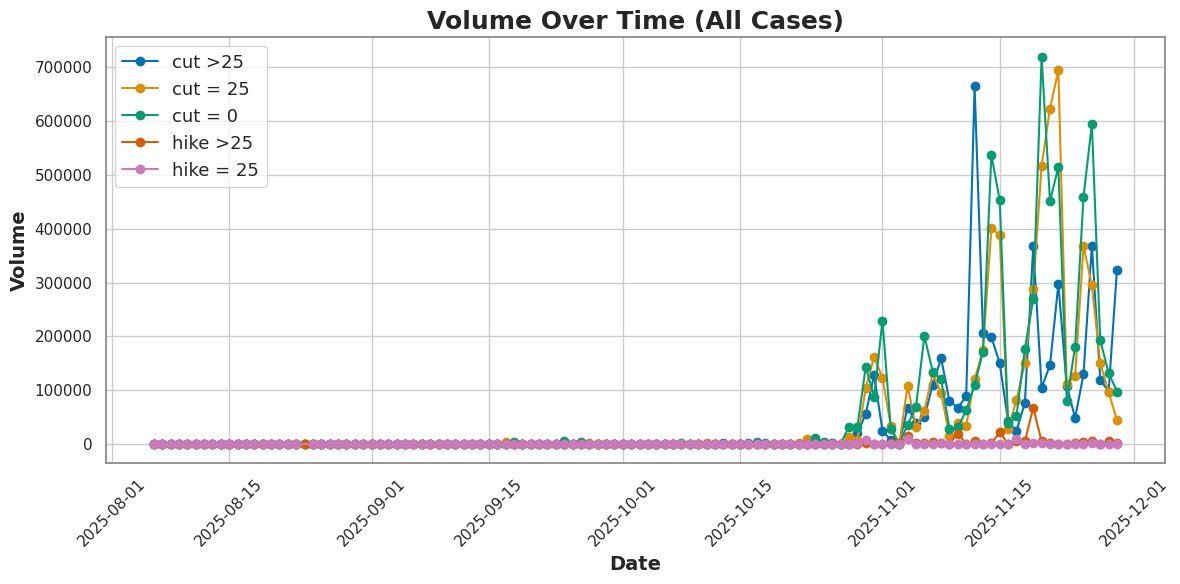

In [127]:
plt.figure(figsize=(12, 6))
vol_cols = [col for col in df_merged.columns if col.endswith('_volume')]
for col in vol_cols:
    df_plot = df_merged.dropna(subset=[col])
    plt.plot(pd.to_datetime(df_plot['end_period']), df_plot[col], marker='o', label=col.replace('_volume', ''))
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Volume Over Time (All Cases)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [156]:
fed_df = pd.read_csv('FedMeeting_20251210.csv')

In [157]:
# Current Fed Funds Target Rate is 4% (i.e., 400-425 bps band)
# So: 
#   <400 is a cut; =400-425 is unchanged; >425 is a hike.

fed_df = fed_df.loc[:, [
    'Date',
    '(350-375)',   # 0.25% cut from current band (to 3.50-3.75%)
    '(375-400)',   # 0.25% cut from current upper band (to 3.75-4.00%)
    '(400-425)',   # holds at current rate (4.00-4.25%)
]]


fed_df.head()

,Date,(350-375),(375-400),(400-425)
0,11/29/2024,0.235567,0.286113,0.209517
1,12/2/2024,0.226570,0.287744,0.220979
2,12/3/2024,0.249192,0.288893,0.196104
3,12/4/2024,0.271625,0.277911,0.162658
4,12/5/2024,0.254527,0.284221,0.186805


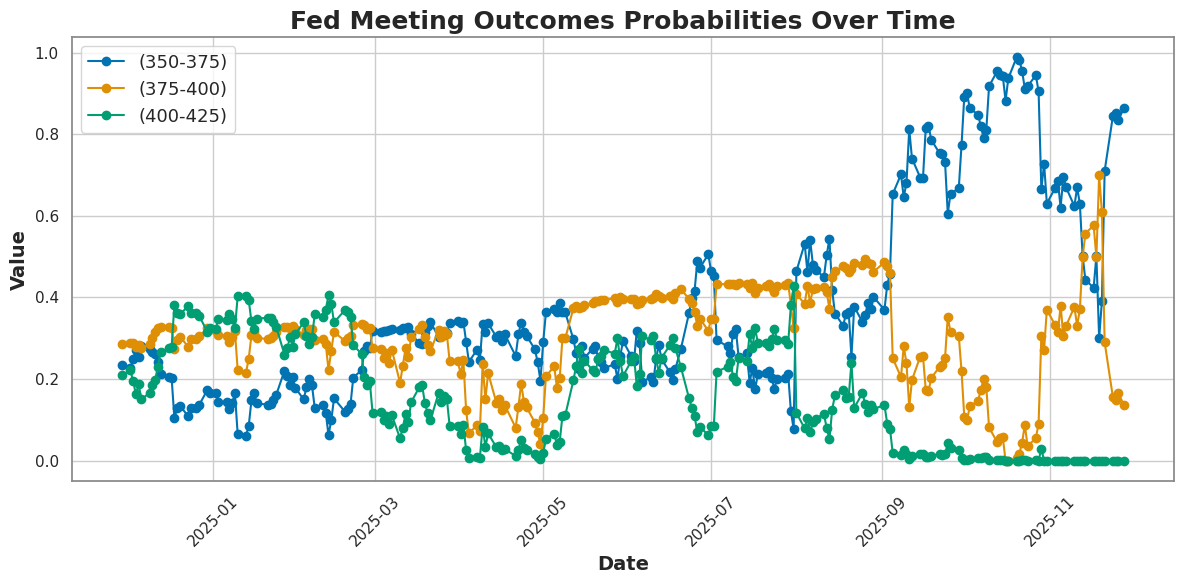

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for col in fed_df.columns[1:]:
    plt.plot(pd.to_datetime(fed_df['Date']), fed_df[col], marker='o', label=col)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Fed Meeting Outcomes Probabilities Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [159]:
# First, parse dates to datetime for both DataFrames
fed_df['Date'] = pd.to_datetime(fed_df['Date'])
df_merged['end_period'] = pd.to_datetime(df_merged['end_period'])

# Merge on date, inner join
merged_df = pd.merge(df_merged, fed_df, left_on='end_period', right_on='Date', how='inner')


In [160]:
merged_oct = merged_df[merged_df['end_period'].dt.month >= 10]

In [161]:
merged_oct = merged_oct.fillna(method='ffill')


C:\Users\jmani\AppData\Local\Temp\ipykernel_16396\3619962920.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_oct = merged_oct.fillna(method='ffill')


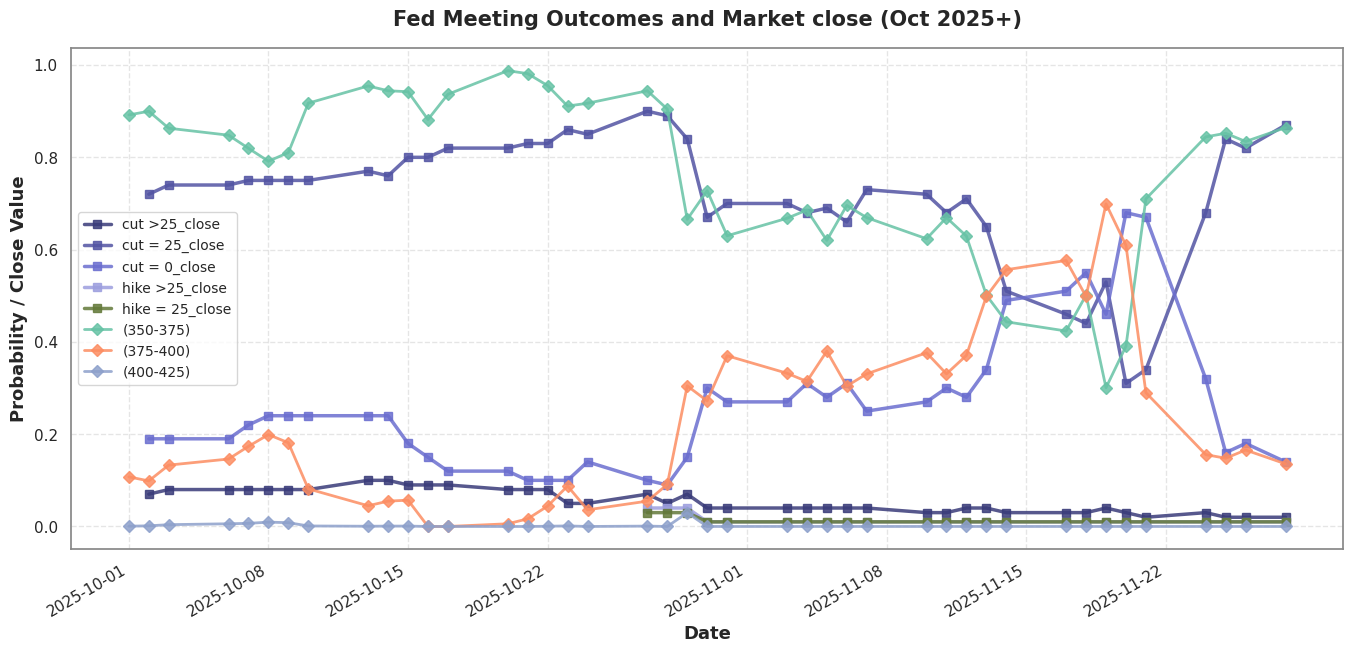

In [164]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Identify columns
probability_cols = [col for col in merged_oct.columns if (
    col.endswith('_cme') or col in ['->25_cme', '-25_cme', '=0_cme', '+>25_cme']
)]
close_cols = [col for col in merged_oct.columns if col.endswith('_close')]
fed_bands = ["(350-375)", "(375-400)", "(400-425)", "(425-450)"]
band_cols = [col for col in fed_bands if col in merged_oct.columns]

all_cols_to_plot = probability_cols + close_cols + band_cols

if all_cols_to_plot:
    plt.figure(figsize=(14, 7))

    # Pre-assign unique, human-friendly colors to each group for clarity
    # "tab10" for major groupings, "Set2"/"tab20" for within groups if more variety needed
    from cycler import cycler

    palette_prob = plt.get_cmap('tab10')
    palette_close = plt.get_cmap('tab20b')
    palette_band = plt.get_cmap('Set2')

    group_styles = [
        (probability_cols, "Probabilities", palette_prob, 'o', 2),
        (close_cols, "Market Close", palette_close, 's', 2.5),
        (band_cols, "CME Bands", palette_band, 'D', 2)
    ]
    line_objs = []

    color_i = 0
    for group_cols, group_label, cmap, marker, lw in group_styles:
        # Assign unique colors to each column in the group, but different palettes for each group
        for i, col in enumerate(group_cols):
            if len(group_cols) == 1:
                color = cmap(0)
            else:
                color = cmap(i % cmap.N)
            line, = plt.plot(
                merged_oct['end_period'], merged_oct[col], 
                label=col, 
                marker=marker, 
                alpha=0.85, 
                linewidth=lw, 
                color=color
            )
            line_objs.append(line)
        color_i += 1

    # Neat date formatting
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
    plt.xticks(rotation=30, ha='right')

    plt.xlabel('Date', fontsize=13)
    plt.ylabel('Probability / Close Value', fontsize=13)
    plt.title('Fed Meeting Outcomes and Market close (Oct 2025+)', fontsize=15, pad=16)
    plt.legend(fontsize=10, frameon=True)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout(pad=2)
    plt.show()
else:
    print("No probability, _close, or CME band columns found in merged_oct DataFrame.")


Columns with |correlation| > 0.6 between bracket columns ((350-375), (375-400), (400-425)) and _close columns:
(350-375) & cut >25_close: 0.62
(350-375) & cut = 25_close: 0.77
(350-375) & cut = 0_close: -0.79
(375-400) & cut >25_close: -0.64
(375-400) & cut = 25_close: -0.78
(375-400) & cut = 0_close: 0.79


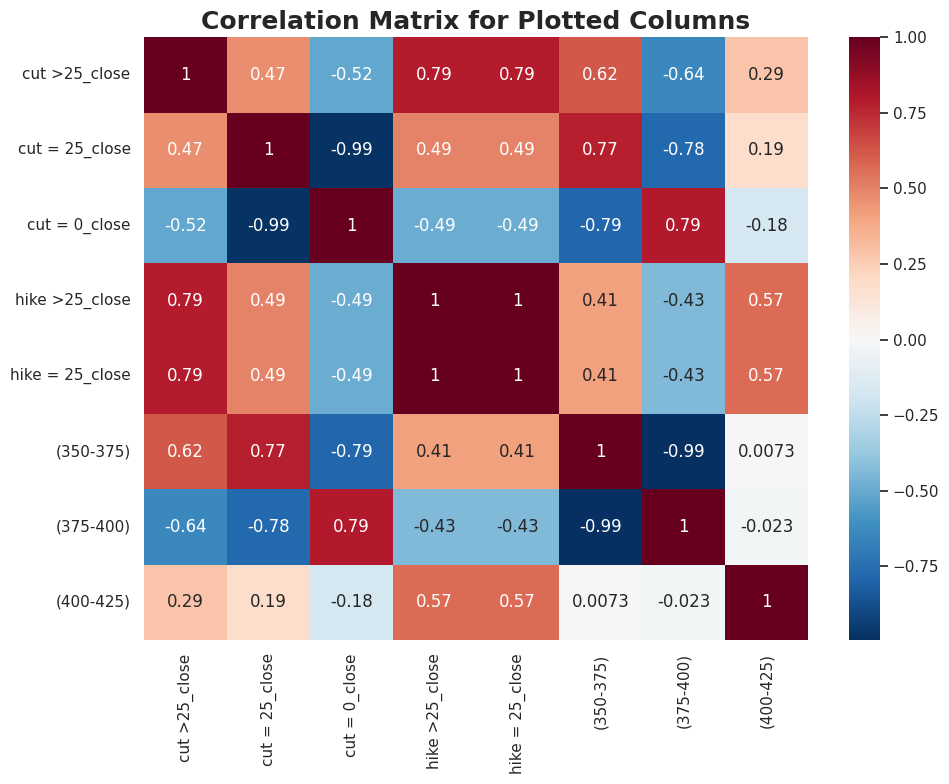

In [165]:
import seaborn as sns

# Compute correlation for the columns that were selected for plotting
corr_matrix = merged_oct[all_cols_to_plot].corr()

# Print out columns with high correlation (|corr| > threshold) between bracket columns and columns ending with '_close'
threshold = 0.6
bracket_cols = [col for col in corr_matrix.columns if col in fed_bands]
close_cols_corr = [col for col in corr_matrix.columns if col.endswith('_close')]
printed = set()
print(f"Columns with |correlation| > {threshold} between bracket columns ({', '.join(bracket_cols)}) and _close columns:")
for bracket_col in bracket_cols:
    for col in close_cols_corr:
        if col != bracket_col:
            corr_value = corr_matrix.loc[bracket_col, col]
            if abs(corr_value) > threshold and (bracket_col, col) not in printed and (col, bracket_col) not in printed:
                print(f"{bracket_col} & {col}: {corr_value:.2f}")
                printed.add((bracket_col, col))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Matrix for Plotted Columns")
plt.tight_layout()
plt.show()


c:\Users\jmani\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jmani\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


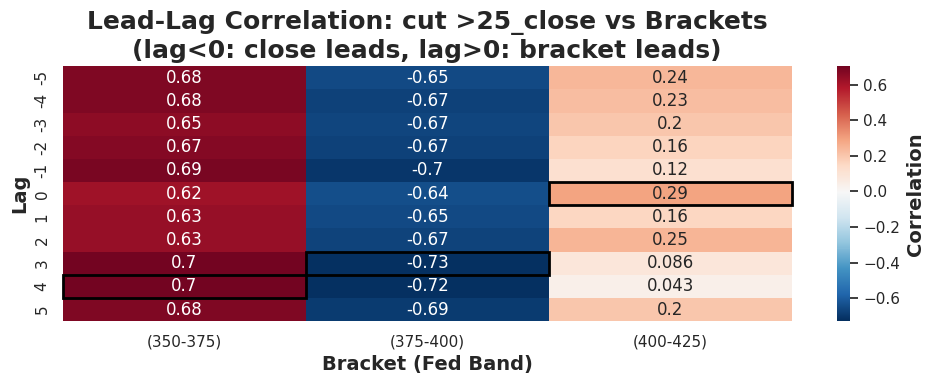

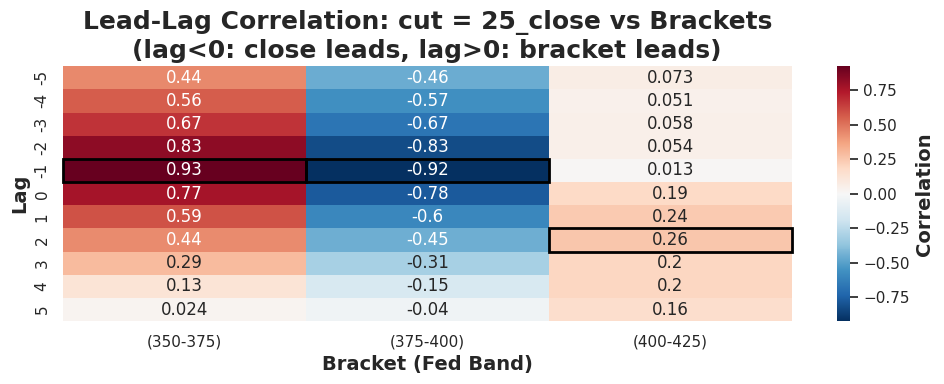

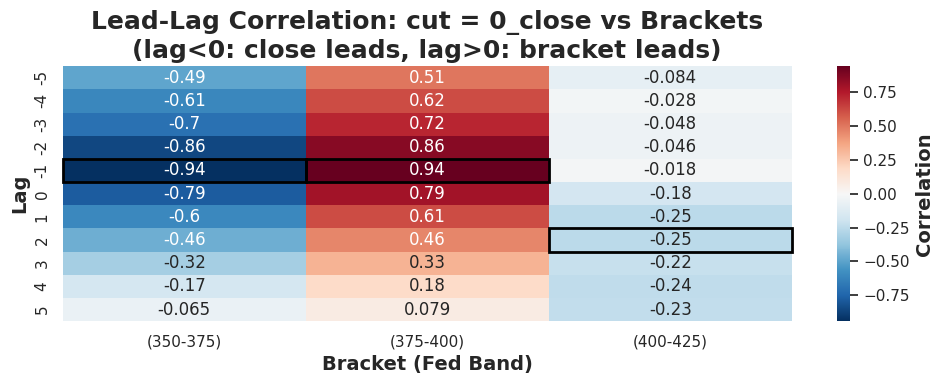

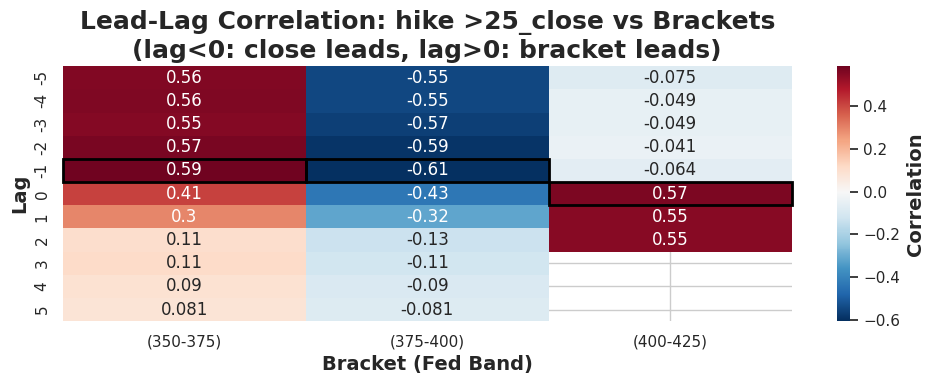

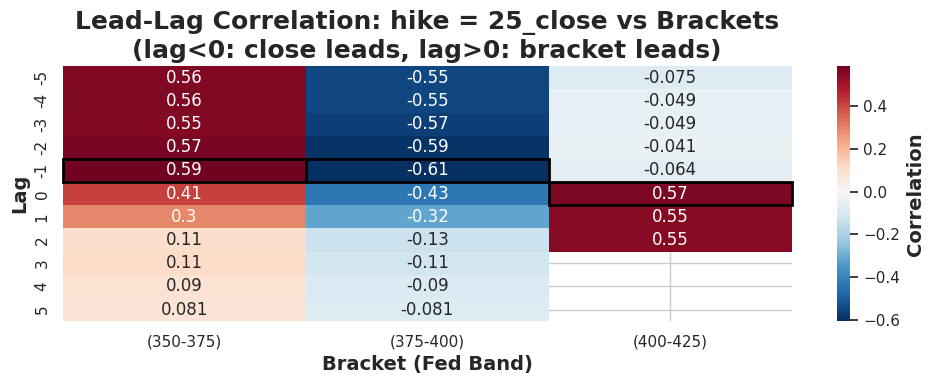

In [166]:
# Fixed Lead-lag analysis (plot neatly, no print statements)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

lead_lag_results = []

max_lag = 5  # you can adjust lag window if desirable

# Defensive: Only keep columns in merged_oct that are present
existing_close_cols = [col for col in close_cols_corr if col in merged_oct.columns]
existing_bracket_cols = [col for col in bracket_cols if col in merged_oct.columns]

if existing_close_cols and existing_bracket_cols:
    for close_col in existing_close_cols:
        for bracket_col in existing_bracket_cols:
            for lag in range(-max_lag, max_lag + 1):
                shifted = merged_oct[bracket_col].shift(-lag)
                corr = merged_oct[close_col].corr(shifted)
                if not np.isnan(corr):
                    lead_lag_results.append({
                        'close_col': close_col,
                        'bracket_col': bracket_col,
                        'lag': lag,
                        'correlation': corr
                    })
    if lead_lag_results:
        lead_lag_df = pd.DataFrame(lead_lag_results)

        # For each (close, bracket) pair, highlight lag with max |corr| on the heatmap with a black square
        for close_col in existing_close_cols:
            plt.figure(figsize=(10, 4))
            data = lead_lag_df[lead_lag_df['close_col'] == close_col].pivot(index='lag', columns='bracket_col', values='correlation')
            ax = sns.heatmap(data, annot=True, cmap="RdBu_r", center=0, cbar_kws={"label": "Correlation"})

            # Optionally, add black box for lag with max |corr| for each bracket
            for bracket in data.columns:
                series = data[bracket]
                if not series.isnull().all():
                    best_lag = series.abs().idxmax()
                    y = data.index.get_loc(best_lag)
                    x = data.columns.get_loc(bracket)
                    ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='black', lw=2, clip_on=False))

            plt.title(f"Lead-Lag Correlation: {close_col} vs Brackets\n(lag<0: close leads, lag>0: bracket leads)")
            plt.xlabel("Bracket (Fed Band)")
            plt.ylabel("Lag")
            plt.tight_layout()
            plt.show()
    # else: do nothing
# else: do nothing
